# Einsendeaufgabe 3: Numba (100 Punkte)

In diesem Abschnitt möchten wir unsere Applikationen mit Numba beschleunigen.

## Mandelbrot-Set (10 Punkte)

Wir beginnen mit einem klassischen Beispiel für Parallelisierung: dem Mandelbrot-Set.

Die Mandelbrot-Menge wird durch die Gleichung $z_{n+1} = z_n^2 + c$ beschrieben. In dieser Gleichung sind $c$ und $z$ komplexe Zahlen, und $n$ ist Null oder eine positive ganze Zahl. Ausgehend von $z_0=0$, gehört $c$ zur Mandelbrot-Menge, wenn der Absolutwert von $z_n$ niemals größer als eine bestimmte Zahl wird (diese Zahl ist abhängig von $c$), egal wie groß $n$ wird.

Das bedeutet, eine komplexe Zahl $c$ ist ein Element der Mandelbrotmenge, wenn die Beträge der mit diesem $c$ berechneten $z_{n}$ nicht unbegrenzt wachsen, unabhängig davon, wie groß $n$ wird. Es lässt sich leicht zeigen, dass der Betrag von $z_{n}$ unbegrenzt wächst, sobald ein $z_{n}$ mit $|z_{n}|>2$ auftritt.

Bei der Berechnung des Mandelbrot-Sets legt man oft eine obere Grenze für die maximalen Iterationen fest, um zu testen, ob diese überschritten wird.

Ein einfacher Algorithmus zur Bestimmung, ob ein Wert zum Mandelbrot-Set gehört, sieht folgendermaßen aus:

In [ ]:
import numba
import numpy as np


def escape_time(p, maxiter):
    """
    Führt die Mandelbrot-Iteration für einen Punkt p in der komplexen Ebene durch,
    um zu bestimmen, ob p zur Mandelbrot-Menge gehört.

    Parameter
    ---------
    p : complex
        Ein einzelner Punkt in der komplexen Ebene (z. B. 0.3 + 0.5j)

    maxiter : int
        Maximale Anzahl an Iterationen, nach denen p als zur Mandelbrot-Menge gehörig
        angenommen wird, wenn die Folge nicht „entweicht“.

    Rückgabewert
    ------------
    i : int
        Anzahl der Iterationen, bis die Folge entweicht (|z| > 2),
        oder maxiter, falls sie stabil bleibt.
    """

    z = 0j  # Startwert der rekursiven Folge ist die komplexe Zahl 0 + 0j

    for i in range(maxiter):  # Schleife führt maximal 'maxiter' Iterationen durch
        z = z**2 + p  # Mandelbrot-Iteration: z_{n+1} = z_n² + p
        if abs(z) > 2:  # Sobald der Betrag von z größer als 2 wird ...
            return i   # ... gilt p als „aus der Menge entkommen“ – also nicht in der Mandelbrot-Menge

    # Wenn die Schleife vollständig durchlaufen wurde, ohne dass |z| > 2:
    return maxiter  # --> p ist vermutlich in der Mandelbrot-Menge

a = np.array([0.2 + 0.2j])  # komplexe Zahl als NumPy-Array
escape_time(a, 400) # Problemchen: Die Funktion escape_time erwartet eine einzelne komplexe Zahl, kein Array von komplexen Zahlen!
                    #  Richtige Verwendung: escape_time(0.2 + 0.2j, 400) 

Die Zahl $0.2+0.2j$ liegt also in der Mandelbrot Menge, da wir nach 400 Iterationen noch nicht die Abbruchbedingung erfüllen.  Allerdings ist es mühsam, jede Zahl einzeln zu testen. Wir erstellen also ein 2-D Feld mit vielen Komplexen Zahlen $|z|<2$: 

In [ ]:
real_param = (-1.5, 1.1, 1500) # Tupel mit drei Werten: (Start, Stop, Anzahl Schritte) für den realen Teil der komplexen Zahl
imag_param = (-1.5j, 1.1j, 1500) # Tupel mit drei Werten: (Start, Stop, Anzahl Schritte) für den imaginären Teil der komplexen Zahl

# Von -1.5 bis 1.1, in 1500 Schritten (für die x-Achse bzw. den Realteil der komplexen Zahlen)
# Von -1.5j bis 1.1j, auch in 1500 Schritten (für die y-Achse bzw. den Imaginärteil)
# z. B. p.linspace(*(-1.5, 1.1, 1500)) wird zu np.linspace(-1.5, 1.1, 1500). 
# Der Stern ist ist ein "Unpacking Operator" in Python.
XX, YY = np.meshgrid(np.linspace(*real_param), np.linspace(*imag_param))

# Erzeugt ein 2D-Feld komplexer Zahlen aus den Gitterpunkten:
# XX enthält die Realteile, YY die Imaginärteile → ergibt die komplexen Zahlen c = x + iy
P = XX + YY

<!-- BEGIN QUESTION -->

**Aufgabe:**  
- Vektorisieren Sie die Funktion mit `np.vectorize`
- Vektorisieren Sie die Funktion mit `numba.vectorize`
- Testen Sie, ob der Parallel-Parameter funktioniert und ob er Performance-Vorteile bringt
- Vergleichen Sie die Laufzeit der drei Versionen und stellen Sie den Vergleich graphisch dar

_Points:_ 7

<span style="color: brown;" title="Ahmed">

## Vektorisierung mit `np.vectorize` und `numba.vectorize` – inklusive Performance-Vergleich

In dieser Aufgabe berechnen wir die Mandelbrot-Menge mithilfe des *Escape-Time-Verfahrens*. Dabei wird für jeden Punkt der komplexen Ebene iterativ überprüft, ob die Folge $z_{n+1} = z_n^2 + p$ den Betrag 2 überschreitet. Die Anzahl der benötigten Iterationen bis zum Überschreiten (oder Erreichen des Maximums) nennt man *Escape-Time*.

Das Verfahren ist rechenintensiv – ideal, um verschiedene Optimierungsansätze durch **Vektorisierung** zu vergleichen. Vektorisierung bedeutet hier: Wir formulieren die Escape-Time-Funktion so, dass sie auf ganze Arrays gleichzeitig angewendet werden kann, was die Rechenleistung erheblich steigern kann.

Wir untersuchen drei Varianten:

1. **`np.vectorize`** – einfache Anwendung auf Arrays, aber ohne echte Performance-Vorteile (nur syntaktischer Zucker).
2. **`numba.vectorize`** – Just-in-Time-Kompilierung zu Maschinencode für echte Geschwindigkeitsgewinne.
3. **`numba.vectorize(..., target='parallel')`** – zusätzlich mit Multi-Core-Parallelausführung.

Wir messen und vergleichen die Ausführungszeiten mit `timeit`, um zu zeigen, wie sich die Wahl der Methode auf die Rechenzeit auswirkt – besonders bei hochauflösenden Bilddaten.


</span>

In [ ]:
import numba                     # Für Performance-Optimierung durch JIT-Kompilierung
import numpy as np               # Für numerische Operationen und Arrays
import timeit                    # Zum Messen der Ausführungszeit
import matplotlib.pyplot as plt  # Zum Visualisieren der Mandelbrot-Menge

# -------------------------------------------------------------------
# ESCAPE-TIME-FUNKTION (Skalare Version ohne Beschleunigung)
def escape_time(p, maxiter): #  Prüft für einen komplexen Punkt p, ob er zur Mandelbrot-Menge gehört.
    z = 0j  # Startwert z = 0 (komplexe Zahl 0 + 0j)
    for i in range(maxiter):
        z = z*z + p     # Iterationsformel (Mandelbrot-Iteration)
        if np.abs(z) > 2:  # Wenn Betrag > 2, verlässt die Folge die Menge
            return i    # Anzahl der benötigten Schritte wird zurückgegeben
    return maxiter      # Wenn nie > 2, gehört p zur Mandelbrot-Menge
                        # Reine Python-Logik. Langsam, da sie keine Vektorisierung oder JIT-Optimierung nutzt.

# -------------------------------------------------------------------
# VARIANTE 1: np.vectorize (bequem, aber langsam)
def mandelbrot_set_np_vectorized(P, maxiter):
    vectorized_escape_time = np.vectorize(escape_time)  # Vektorisierung der skalaren Funktion
    return vectorized_escape_time(P, maxiter) # Anwendung auf ganzes Gitter von komplexen Zahlen

# -------------------------------------------------------------------
# VARIANTE 2: numba.vectorize (mit JIT-Kompilierung)
#  Just-in-Time-Kompilierung via numba
@numba.vectorize(['int32(complex128, int32)']) # erzeugt eine vektorisierte ufunc (universal function)
def escape_time_numba(p, maxiter): 
    z = 0j  
    for i in range(maxiter):
        z = z*z + p  
        if np.abs(z) > 2:  
            return i
    return maxiter # Deutlich schneller als NumPy-Vektorversion!

# -------------------------------------------------------------------
# VARIANTE 3: numba.vectorize mit Parallelisierung
# wie VARIANTE 2, aber zusätzlich wird die Funktion intern multithreaded ausgeführt (wenn möglich), durch target='parallel'
@numba.vectorize(['int32(complex128, int32)'], target='parallel')
def escape_time_numba_par(p, maxiter):
    z = 0j  
    for i in range(maxiter):
        z = z*z + p  
        if np.abs(z) > 2:  
            return i
    return maxiter # Funktioniert nur dann richtig schnell, wenn das Eingabe-Array groß genug ist und das System Parallelisierung unterstützt.

# -------------------------------------------------------------------
# Berechnung der Mandelbrot-Menge mit der parallelisierten numba-Version
def mandelbrot_set_numba_vectorized_par(P, maxiter):
    return escape_time_numba_par(P, maxiter)

# Neue Funktion für den `numba.vectorize` ohne Parallelisierung
def mandelbrot_set_numba_vectorized(P, maxiter):
    return escape_time_numba(P, maxiter)

# -------------------------------------------------------------------
# Benchmarking: Messung der Laufzeit der verschiedenen Varianten
def timed_run(func):
    start = timeit.default_timer()
    result = func() # Ein 2D-Array, das die Anzahl der Iterationen für jede komplexe Zahl im Array P angibt.
    end = timeit.default_timer()
    return result, round(end - start, 4)

# -------------------------------------------------------------------
# Code wurde bereits in der oberen Codezelle erläutert, hier nochmal der Vollständigkeitshalber angegeben:
real_param = (-1.5, 1.1, 1500) 
imag_param = (-1.5j, 1.1j, 1500) 
XX, YY = np.meshgrid(np.linspace(*real_param), np.linspace(*imag_param))
P = XX + YY

# -------------------------------------------------------------------
# Maximaler Wert für die Iterationen
# Dieser Wert beeinflusst die Detailtiefe. 
# Wenn man tiefere Bereiche der Mandelbrot-Menge untersuchen möchte, dann
# muss dieser Wert erhöht werden (z. B. 1000 oder 2000), allerdings auf Kosten der Performance.
maxiter = 200 

# Messen der Zeiten für verschiedene Varianten
M_np_vectorized, time_np_vectorized = timed_run(lambda: mandelbrot_set_np_vectorized(P, maxiter))
M_numba_vectorized, time_numba_vectorized = timed_run(lambda: mandelbrot_set_numba_vectorized(P, maxiter))
M_numba_vectorized_par, time_numba_vectorized_par = timed_run(lambda: mandelbrot_set_numba_vectorized_par(P, maxiter))

# Ausgabe der Laufzeiten
print(f"Zeit für np.vectorize: {time_np_vectorized:.4f} Sekunden")
print(f"Zeit für numba.vectorize: {time_numba_vectorized:.4f} Sekunden")
print(f"Zeit für numba.vectorize (parallel): {time_numba_vectorized_par:.4f} Sekunden")

<!-- END QUESTION -->

Mit *plt.imshow(M)* können Sie sich die Mandelbrotmenge $M$ ansehen: 

In [ ]:
# -------------------------------------------------------------------
# Visualisierung der Mandelbrot-Menge
plt.imshow(M_numba_vectorized_par, cmap='viridis',
           extent=[real_param[0] , real_param[1], imag_param[0].imag , imag_param[1].imag],
           origin='lower')
           # extent=[xmin, xmax, ymin, ymax]=
           # .imag ist ein Attribut von komplexen Zahlen, das den Imaginärteil der Zahl gibt.
           # origin='lower' sorgt dafür, dass die Y-Achse nach oben zeigt (mathematische Orientierung), 
           # statt nach unten (wie bei Bildkoordinaten üblich).
plt.axis('on')
plt.title("Mandelbrot-Menge (parallelisiert)", fontsize=14)
plt.colorbar()
plt.show()

In [ ]:
# Graphischer Vergleich der Laufzeiten:

# Laufzeiten für jede Variante
methoden = ['np.vectorize', 'numba.vectorize', 'numba.vectorize (parallel)']
laufzeiten = [time_np_vectorized, time_numba_vectorized, time_numba_vectorized_par]

# 1. Diagramm: alle
plt.figure(figsize=(10, 6))  # Neues Diagramm
plt.bar(methoden[:], laufzeiten[:], color=['blue', 'green', 'red'])  # Nur np.vectorize
plt.xlabel('Methode')
plt.ylabel('Laufzeit in Sekunden')
plt.title('Alle Methoden im Performance-Vergleich')

# Anzeige der Werte auf den Balken
for i, v in enumerate(laufzeiten[:]):
    plt.text(i, v + 0.02, f'{v:.4f}s', ha='center', va='bottom', fontsize=12)
    
# Achsenbegrenzung setzen
plt.ylim(0, max(laufzeiten) + 5) 

# Diagramm anzeigen
plt.tight_layout()
plt.show()

# 2. Diagramm: numba.vectorize & numba.vectorize (parallel)
plt.figure(figsize=(10, 6)) 
plt.bar(methoden[1:], laufzeiten[1:], color=['green', 'red'])  # numba.vectorize und numba.vectorize (parallel)
plt.xlabel('Methode')
plt.ylabel('Laufzeit in Sekunden')
plt.title('Performance-Vergleich von numba.vectorize & numba.vectorize (parallel)')

# Anzeige der Werte auf den Balken
delta = 0.01
for i, v in enumerate(laufzeiten[1:]):
    plt.text(i, v + delta/10, f'{v:.4f}s', ha='center', va='bottom', fontsize=12)

# Achsenbegrenzung setzen

plt.ylim(min(laufzeiten[1:])-delta, max(laufzeiten[1:])+delta)

# feinere Unterteilung der y-Achse
plt.yticks(np.arange(min(laufzeiten[1:])-delta, max(laufzeiten[1:])+delta, 0.005))

# Diagramm anzeigen
plt.tight_layout()
plt.show()

<!-- BEGIN QUESTION -->

**Aufgabe:** Vergleichen Sie nun die drei Versionen mit Scalene. Verwenden sie eine Sampling-Rate von $0.0001$

_Points:_ 3

<span style="color: brown;" title="Ahmed">

## Vektorisierung mit `np.vectorize` und `numba.vectorize` – inklusive Performance-Vergleich

In dieser Aufgabe berechnen wir die Mandelbrot-Menge mithilfe des *Escape-Time-Verfahrens*. Dabei wird für jeden Punkt der komplexen Ebene iterativ überprüft, ob die Folge $z_{n+1} = z_n^2 + p$ den Betrag 2 überschreitet. Die Anzahl der benötigten Iterationen bis zum Überschreiten (oder Erreichen des Maximums) nennt man *Escape-Time*.

Das Verfahren ist rechenintensiv – ideal, um verschiedene Optimierungsansätze durch **Vektorisierung** zu vergleichen. Vektorisierung bedeutet hier: Wir formulieren die Escape-Time-Funktion so, dass sie auf ganze Arrays gleichzeitig angewendet werden kann, was die Rechenleistung erheblich steigern kann.

Wir untersuchen drei Varianten:

1. **`np.vectorize`** – einfache Anwendung auf Arrays, aber ohne echte Performance-Vorteile (nur syntaktischer Zucker).
2. **`numba.vectorize`** – Just-in-Time-Kompilierung zu Maschinencode für echte Geschwindigkeitsgewinne.
3. **`numba.vectorize(..., target='parallel')`** – zusätzlich mit Multi-Core-Parallelausführung.

Wir messen und vergleichen die Ausführungszeiten mit `timeit`, um zu zeigen, wie sich die Wahl der Methode auf die Rechenzeit auswirkt – besonders bei hochauflösenden Bilddaten.


</span>

In [ ]:
%load_ext scalene

In [ ]:
%%scalene --cpu-only --cpu-sampling-rate 0.0001

import numpy as np
import numba
import time

# Originale Version mit reiner Python-Iteration
def escape_time(p, maxiter):
    z = 0j
    for i in range(maxiter):
        z = z*z + p
        if abs(z) > 2:
            return i
    return maxiter

# NumPy-Vectorize Version (langsam, nur syntaktisch)
def mandelbrot_set_np_vectorized(P, maxiter):
    vec_escape = np.vectorize(escape_time)
    return vec_escape(P, maxiter)

# Numba-Vektorisierung (schnell)
@numba.vectorize(['int32(complex128, int32)'], nopython=True)
def escape_time_numba(p, maxiter):
    z = 0j
    for i in range(maxiter):
        z = z*z + p
        if abs(z) > 2:
            return i
    return maxiter

def mandelbrot_set_numba_vectorized(P, maxiter):
    return escape_time_numba(P, maxiter)

# Numba mit Parallelisierung (schnell + multi-core)
@numba.vectorize(['int32(complex128, int32)'], target='parallel')
def escape_time_numba_par(p, maxiter):
    z = 0j
    for i in range(maxiter):
        z = z*z + p
        if abs(z) > 2:
            return i
    return maxiter

def mandelbrot_set_numba_vectorized_par(P, maxiter):
    return escape_time_numba_par(P, maxiter)

# Gemeinsame Eingabedaten vorbereiten (reduzierte Auflösung für Profiling)
real_param = (-1.5, 1.1, 300)
imag_param = (-1.5j, 1.1j, 300)
XX, YY = np.meshgrid(np.linspace(*real_param), np.linspace(*imag_param))
P = XX + YY
maxiter = 200

# Ausführung der Funktionen zur Profilierung
_ = mandelbrot_set_np_vectorized(P, maxiter)        # _ = ... Führe die Funktion aus, aber ich brauche das Ergebnis nicht. Der Rückgabewert belastet den Speicher nicht unnötig.
_ = mandelbrot_set_numba_vectorized(P, maxiter)
_ = mandelbrot_set_numba_vectorized_par(P, maxiter)


<span style="color: brown;" title="Ahmed">

### Scalene-Ausgabe

- **Time Python**:
    - Diese Zeit zeigt an, wie lange der Python-Interpreter für das Ausführen von Code benötigt hat.
    - Sie umfasst alle Python-spezifischen Berechnungen, die in der Programmausführung stattfinden.
  
- **Native**:
    - Diese Zeit bezieht sich auf den Code, der direkt von der CPU ausgeführt wird, nachdem er von einem Just-In-Time (JIT) Compiler (wie bei Numba) oder einem externen Programm wie C oder Fortran kompiliert wurde.
    - Hier wird die Zeit angezeigt, die durch optimierte, kompilierte Funktionen genutzt wird, z. B. bei der Nutzung von Numba.

- **System**:
    - Diese Zeit zeigt die Systemaufrufe und Betriebssystemoperationen, die von Python während der Programmausführung ausgeführt werden.
    - Dazu gehören z. B. Speicheroperationen, Dateioperationen oder die Kommunikation mit anderen Prozessen.

### Fazit

Die Analyse mit **Scalene** zeigt, dass durch die Optimierung des Mandelbrot-Set-Algorithmus mit **Numba** und **Parallelisierung** signifikante Performance-Steigerungen erzielt werden können. Insgesamt zeigt sich, dass die Kombination von **Numba mit Parallelisierung** die optimale Lösung für eine schnelle Berechnung der Mandelbrot-Menge darstellt und eine deutlich bessere Performance als die anderen Ansätze bietet.
 
- **Die Numba-Optimierung** (mit `@numba.vectorize`) ermöglicht die Ausführung im **kompilierten Code**, was die Performance deutlich verbessert und **einen großen Anteil der Gesamtzeit** auf native Berechnungen verlagert.
- **Die Parallelisierung mit Numba** (mit `@numba.vectorize(..., target='parallel')`) erzielt den größten Performance-Gewinn, indem die Berechnungen auf mehreren CPU-Kernen parallel ausgeführt werden. Dies führt zu einer **deutlich reduzierten Python-Zeit** und maximiert die Effizienz der Berechnungen.

</span>

<!-- END QUESTION -->

## Springende Bälle, Teil 2 (60 Punkte)
Wir wollen die Simulation mit mehreren Bällen verbessern und optimieren. 

Jetzt werden zusätzlich Kollisionen zwischen den Bällen beachtet.
Dafür wollen wir zunächst berechnen, ob die Bälle in einem Zeitschritt kollidieren. Eine genaue Berechnung ist hier sehr schwer, daher können wir dies nur näherungsweise machen. Wir müssen dazu auch folgende Annahmen machen:

1. Die Bälle haben einen Radius von $r$, alle Bälle sind gleich groß 
2. Der Zeitschritt $\Delta t$ und die Geschwindigkeit $\$v$ der Bälle sind so gewählt, dass ein Ball maximal viermal seinen Radius in einem Zeitschritt zurücklegt, also $v*\Delta t <= 4*r$


Wir berechnen nun in jeden Zeitschritt zunächst 3 zusätzliche Zwischenzeitschritte:

$ c_0 = c_0$

$c_1 = c_0+0.25\Delta t *v$

$c_3 = c_0+0.5\Delta t *v$

$c_4 = c_0+0.75\Delta t * v$

(Der nächste Schritt wäre $\Delta t$, dieser wird aber in der nächsten Iteration beachtet.)


Wir betrachten nun jeweils für 2 Bälle, ob sie sich in einem der Zwischenzeitschritte näher als zweimal dem Radius $r$ kommen. Wenn sie das tun, gibt es eine Kollision.

<!-- BEGIN QUESTION -->

**Aufgabe:** Schreiben Sie eine Funktion, die dies für zwei Bälle testet und zunächst `True` oder `False` zurück gibt. Für die Berechnung des Abstands können sie die Funktion `np.linalg.norm` verwenden.

_Points:_ 10

In [5]:
import numpy as np

def will_collide(c1, c2, v1, v2, r1, r2, dt):
    """
    Prüft, ob zwei Bälle sich innerhalb eines Zeitschritts dt kollidieren werden

    Parameter:
    - c1, c2:   Positionen von Ball 1 und 2 
    - v1, v2:   Geschwindigkeiten von Ball 1 und 2
    - r1, r2:   Radien von Ball 1 und 2
    - dt:       Zeitschritt

    Rückgabewerte:
    - collided:                 Status: Ob eine Kollision erkannt wurde      
    - k_frac:                   Fraktion des Zeitschritts, bei dem die Kollision stattfindet
    - c1_before, c2_before:     Positionen von Ball 1 und 2 vor der Kollision
    """

    # Vorinitialisierung
    collided = False
    k_frac = 0
    c1_before = c1
    c2_before = c2
    k_values = [0, 0.25, 0.5, 0.75]  # Zeitanteile innerhalb des Zeitschritts

    for k in k_values:
        # Positionen der Bälle nach k * dt
        c1_pos = c1 + k * dt * v1
        c2_pos = c2 + k * dt * v2

        # Berechnung des Abstands zwischen den Bällen nach jedem k
        distance = np.linalg.norm(c1_pos - c2_pos)

        # Wenn Abstand kleiner als die Summe der Radien beider Bälle ist -> Kollision
        if distance < (r1 + r2):
            # Aktualisierung der Werte
            collided = True
            k_frac = k
            c1_before = c1_pos
            c2_before = c2_pos
            break  # Kollision gefunden -> Abbruch der Schleife

    return collided, k_frac, c1_before, c2_before


<!-- END QUESTION -->

Um die Geschwindigkeiten der Bälle nach einer Kollision zu berechnen, können wir die Erhaltung des Impulses und die Erhaltung der kinetischen Energie heranziehen, unter der Annahme, dass es sich um eine vollkommen elastische Kollision handelt. Bei einer solchen Kollision bleiben sowohl der Gesamtimpuls als auch die gesamte kinetische Energie des Systems erhalten. Die Berechnungen werden allerdings etwas komplexer, wenn wir Richtungen berücksichtigen.

#### Geschwindigkeiten nach der Kollision

Für zwei Bälle mit Massen $m_1$ und $m_2$, den Anfangsgeschwindigkeiten $v_1$ und $v_2$ und den Endgeschwindigkeiten $v_1'$ und $v_2'$ gelten folgende Gleichungen basierend auf dem Impulserhaltungssatz und der Erhaltung der kinetischen Energie:

1. **Impulserhaltung:**
   $m_1 v_1 + m_2 v_2 = m_1 v_1' + m_2 v_2'$

2. **Erhaltung der kinetischen Energie:**
   $\frac{1}{2} m_1 v_1^2 + \frac{1}{2} m_2 v_2^2 = \frac{1}{2} m_1 {v_1'}^2 + \frac{1}{2} m_2 {v_2'}^2$

Diese Gleichungen müssen vektoriell gelöst werden, da die Geschwindigkeiten Richtungen haben.

Die Lösungen für die Geschwindigkeiten nach der Kollision in zwei Dimensionen unter der Annahme einer vollkommen elastischen Kollision und unter Ignorierung der Rotation der Bälle sind:

$v_1' = v_1 - \frac{2 m_2}{m_1 + m_2} \frac{(v_1 - v_2) \cdot (c_1 - c_2)}{\|c_1 - c_2\|^2} (c_1 - c_2)$

$v_2' = v_2 + \frac{2 m_1}{m_1 + m_2} \frac{(v_1 - v_2) \cdot (c_1 - c_2)}{\|c_1 - c_2\|^2} (c_1 - c_2)$

Hierbei ist $(v_1 - v_2) \cdot (c_1 - c_2)$ das Skalarprodukt der Vektoren $v_1 - v_2$ und $c_1 - c_2$, und $\|c_1 - c_2\|$ ist der Betrag des Vektors $(c_1 - c_2)$, welcher den Abstand zwischen den Zentren der Bälle darstellt.


<!-- BEGIN QUESTION -->

**Aufgabe:** Schreiben Sie eine Funktion, welche die neuen Geschwindigkeiten der Bälle NACH einer Kollision berechnet.  
Sie übergeben der Funktion die folgenden Daten.
- Koordinaten ($c_1, c_2$)
- Geschwindigkeiten ($v_1, v_2$)
- Massen ($m_1, m_2$)

Für die Berechnung des Betrags können Sie wiederum die Funktion `np.linalg.norm` verwenden.

_Points:_ 10

In [ ]:
def collision(c1, c2, v1, v2, m1, m2):
    """
    Berechnet die elastische Kollision zwischen den Bällen 1 und 2
    
    Parameter:
    - c1, c2:   Positionen von Ball 1 und 2 
    - v1, v2:   Geschwindigkeiten von Ball 1 und 2
    - r1, r2:   Radien von Ball 1 und 2
    - m1, m2:   Massen von Ball 1 und 2
    
    Rückgabewerte:
    - v1_new, v2_new:   Neue Geschwindigkeiten von Ball 1 und 2 nach Kollision
    """
    
    # Abstand zwischen den Bällen
    r = c1 - c2
    norm_r = np.linalg.norm(r)  # Betrag des Abstandvektors
    
    # Skalarprodukt der Geschwindigkeitsdifferenz und des Positionsvektors
    v_diff = v1 - v2
    scalar_product = np.dot(v_diff, r)
    
    # Faktor für die Geschwindigkeitsänderung
    factor1 = (2 * m2) / (m1 + m2) * (scalar_product / norm_r**2)
    factor2 = (2 * m1) / (m1 + m2) * (scalar_product / norm_r**2)
    
    # Neue Geschwindigkeiten nach Kollision
    v1_new = (v1 - factor1 * r)
    v2_new = (v2 + factor2 * r)
    
    return v1_new, v2_new


def test_collision(case):
    # Online simulator
    # https://phet.colorado.edu/sims/html/collision-lab/latest/collision-lab_all.html
    if case == "x":
        c1 = np.array([1, 1])
        c2 = np.array([2, 1])
        v1 = np.array([1, 0])
        v2 = np.array([-1, 0])
    if case == "y":
        c1 = np.array([1, 1])
        c2 = np.array([1, 2])
        v1 = np.array([0, 1])
        v2 = np.array([0, -1])
    if case == "diagonal":
        c1 = np.array([1, 1])
        c2 = np.array([2, 2])
        v1 = np.array([1, 1])
        v2 = np.array([0, 0])
    if case == "custom":
        c1 = np.array([1, 1])
        c2 = np.array([2, 3])
        v1 = np.array([1, 1])
        v2 = np.array([0, -1])
    v1_new, v2_new = collision(c1, c2, v1, v2, 1, 1)
    assert np.allclose(np.abs(v2 - v1), np.abs(v2_new - v1_new))
    print(f"{v1=}, {v2=}, {v1_new=}, {v2_new=}")

    # different mass
    v1_new, v2_new = collision(c1, c2, v1, v2, 1, 20)
    assert np.allclose(np.abs(v2 - v1), np.abs(v2_new - v1_new))
    print(f"{v1=}, {v2=}, {v1_new=}, {v2_new=}")


test_collision(case="x")
test_collision(case="y")
test_collision(case="diagonal")
test_collision(case="custom")

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

**Aufgabe:** Nun wollen wir eine Funktion implementieren, die alle möglichen Kollisionen in einem Zeitschritt erfasst und die neuen Geschwindigkeiten der Bälle berechnet – und zwar möglichst effizient. 

Dafür sollten Sie die folgenden Dinge beachten:
1. Es macht nicht für alle Ballpaare sinnvoll alle vier Zwischenzeitschritte zu berechnen. Testen Sie daher zunächst, ob sich zwei Bälle bereits näher als $ 8 \cdot r $ sind.
2. Sie können annehmen, dass sich der Ball bis zum Zwischenschritt, in dem die Kollision berechnet wird, mit der alten Geschwindigkeit bewegt, danach mit der neuen. Implementieren Sie dies entsprechend. Achten Sie auch darauf, dass ein Ball, für den eine Kollision berechnet wurde, im selben Zeitschritt keine vollständige Bewegung für $ \Delta t $ mehr macht.
3. Es kann leicht passieren, dass zwei Bälle, die in einem Zeitschritt kollidieren, es nicht schaffen, sich während des Zeitschritts weit genug aufeinander zu bewegen, sodass sie im folgenden Zeitschritt wieder miteinander kollidieren. Das kann dann dazu führen, dass die Bälle sich umkreisen. Um das zu verhindern, verwenden wir eine Maske (`mask`), die dafür sorgt, dass zwei Bälle nicht in zwei (oder mehr) aufeinanderfolgenden Zeitschritten miteinander kollidieren können.

Anmerkung: Die Situation, dass mehrere Bälle gleichzeitig, in einem Zeitschritt kollidieren, kann hier vereinfacht ignoriert werden.

_Points:_ 10

In [7]:
def get_all_collisions(c, v, m, r, dt, mask, cooldown_frames = 4):
    """
    Prüft und behandelt alle möglichen Kollisionen zwischen Bällen
    
    Parameter:
    - c:                aktuelle Positionen von allen Bällen (Array der Form [N, 2])
    - v:                aktuelle Geschwindigkeiten von allen Bällen (Array der Form [N, 2])
    - m:                aktuelle Massen von allen Bällen (Array der Form [N, 2])
    - r:                aktuelle Radien von allen Bällen (Array der Form [N, 2])
    - dt:               Zeitschritt
    - mask:             Maske, die verhindert, dass Bälle nicht mehreren (=cooldown_frames)  
                        aufeinanderfolgenden Zeitschritten miteinander kollidieren können
    - colldown_frames:  Anzahl der Zeitschritte, bis die Bälle nach einer Kollision
                        wieder für die Berechnung der nächsten Kollision berücksichtigt werden können
    
    Rückgabewerte:
    - c:    Neue Positionen der Bälle nach Kollisionen
    - v:    Neue Geschwindigkeiten der Bälle nach Kollisionen
    - mask: Aktualisierte Maske
    """
    
    N = len(c) # Anzahl der Bälle

    for i in range(N):
        for j in range(i + 1, N):
            
            # Prüfe, ob die Bälle maskiert sind
            if mask[i, j] > 0:
                continue  # Maske anwenden -> Kollision wird nicht überprüft

            # Prüfe, ob die Bälle nah genug sind
            distance = np.linalg.norm(c[i] - c[j])
            min_dist = r[i] + r[j]
            if distance >= 4 * min_dist:
                continue  # Bälle sind noch zu weit voneinander -> Kollision wird nicht überprüft
            
            # Prüfe ob die Kollision schon in diesem Zeitschritt stattfindet
            collided, k_frac, c1_before, c2_before = will_collide(c[i], c[j], v[i], v[j], r[i], r[j], dt)

            if collided:
                # Wenn Kollision, dann neue Geschwindigkeiten
                v1_new, v2_new = collision(c[i], c[j], v[i], v[j], m[i], m[j])
      
                # Neue Position nach der Kollision berechnen 
                c[i] = c1_before + v1_new * (1 - k_frac) * dt # neue Position für Ball 1
                c[j] = c2_before + v2_new * (1 - k_frac) * dt # neue Position für Ball 2
                
                # Aktualisierung von v 
                v[i] = v1_new
                v[j] = v2_new
                
                # Aktualisierung der Maske, wenn Kollisionen aufgetreten sind
                mask[i, j] = cooldown_frames
                mask[j, i] = cooldown_frames                
    
    # Aktualisierung der Maske, wenn keine Kollisionen aufgetreten sind
    mask = np.maximum(mask - 1, 0)
    
    return c, v, mask

In [8]:
# Anfangsbedingungen
g = np.array([0, -9.81], dtype=np.float64)
xmax = 100
ymax = 100
steps = 1000
# dt = xmax * 1e-5
dt = 0.1

# Anzahl Bälle
N = 10

rng = np.random.default_rng(seed=123)

# Flag zur Aktivierung der Visualisierung (Trennung der Simulation und Visualisierung)
visualize = True

# Startpositionen
def init(n=N):
    c = xmax * rng.random((N, 2))
    # Startgeschwindigkeiten, max.
    v = np.array([xmax/10, ymax/10]) * rng.random((N, 2))
    # Masse
    m = rng.uniform(5, 15, size=N)
    r = np.sqrt(m) 
    mask = np.full((N, N), 0, np.int32)
    return c, v, m, r, mask

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

**Aufgabe:** Implementieren Sie nun einen vollständigen Zeitschritt mit Kollisionen. 

_Points:_ 10

In [9]:
def timestep_with_collisions(c, v, m, dt, g, r, xmax, ymax, mask):
    """
    Führt einen vollständigen Zeitschritt mit Kollisionen durch
    
    Parameter:
    - c:                aktuelle Positionen von allen Bällen (Array der Form [N, 2])
    - v:                aktuelle Geschwindigkeiten von allen Bällen (Array der Form [N, 2])
    - m:                aktuelle Massen von allen Bällen (Array der Form [N, 2])
    - dt:               Zeitschritt
    - g:                Gravitationsvektor
    - r:                aktuelle Radien von allen Bällen (Array der Form [N, 2])
    - xmax, ymax:       Begrenzung des Simulationsraums
    - mask:             Maske, die verhindert, dass Bälle nicht in mehreren (=cooldown_frames)  
                        aufeinanderfolgenden Zeitschritten miteinander kollidieren können

    
    Rückgabewerte:
    - c:    Neue Positionen der Bälle nach dt
    - v:    Neue Geschwindigkeiten der Bälle nach dt
    - mask: Aktualisierte Maske
    """
    
    # Gravitation anwenden
    v = v + g * dt
    c += v * dt

    # Kollisionen zwischen Bällen berechnen
    c, v, mask = get_all_collisions(c, v, m, r, dt, mask)

    # Wandkollisionen behandeln
    # Kollisionen mit linken/rechten Wänden
    left_wall = c[:, 0] <= 0 
    right_wall = c[:, 0] >= xmax 
    if np.any(left_wall | right_wall):
        dt2_left_wall = abs(c[left_wall, 0]) / abs(v[left_wall, 0]) 
        dt2_right_wall = (abs(c[right_wall,0]) - xmax) / abs(v[right_wall, 0]) 
        v[left_wall | right_wall, 0] *= -1 
        c[left_wall, 0] = dt2_left_wall * v[left_wall, 0] 
        c[right_wall, 0] = xmax - dt2_right_wall * v[right_wall, 0] 
    # Kollisionen mit oberen/unteren Wänden
    bottom = c[:, 1] <= 0
    top = c[:, 1] >= ymax
    if np.any(bottom | top):
        dt2_bottom = abs(c[bottom, 1]) / abs(v[bottom, 1])
        dt2_top = (abs(c[top, 1]) - ymax) / abs(v[top, 1])
        v[bottom | top, 1] *= -1
        c[bottom, 1] = dt2_bottom * v[bottom, 1]
        c[top, 1] = ymax - dt2_top * v[top, 1]

    return c, v, mask

In [ ]:
# ------------------------------
# HAUPTFUNKTION
# ------------------------------   

# Initialisierung 
c, v, m, r, mask = init()

if visualize == True:
    # Führe Simulation mit Visualisierung durch und animiere das Ergebnis
    all_positions = [c.copy()]

    for i in range(steps):
        c, v, mask = timestep_with_collisions(c, v, m, dt, g, r, xmax, ymax, mask)
        all_positions.append(c.copy())
    
    animate_positions(all_positions, N, xmax, ymax, r, m)
    print("Simulation (mit Visualisierung) war erfolgreich")
else:
    # Nur reine Simulation ohne Visualisierung
    for i in range(steps):
        timestep_with_collisions(c, v, m, dt, g, r, xmax, ymax, mask)
    print("Simulation (ohne Visualisierung) war erfolgreich")

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

**Aufgabe:** Animieren Sie die Bewegung der Bälle.

Tipp: Trennen Sie Simulation und Visualisierung und visualisieren Sie z.B. nur jeden 100. Simulationsschritt. 

_Points:_ 5

In [10]:
# Erstellt eine animierte Visualisierung der Positionen
def animate_positions(all_positions, num_balls, xmax, ymax, r, m, filename="multi_ball_collisions.gif"):
    import matplotlib.pyplot as plt
    from matplotlib.animation import FuncAnimation, PillowWriter
    from matplotlib.patches import Circle
    import numpy as np

    print ("GIF wird erstellt...")
    colors = plt.cm.jet(np.linspace(0, 1, num_balls))

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_xlim(0, xmax)
    ax.set_ylim(0, ymax)
    ax.set_aspect('equal')
    ax.set_title("Simulation: Springende Bälle mit Kollisionen")

    # Bälle erstellen
    circles = []
    for i in range(num_balls):
        circle = Circle((0, 0), r[i], color=colors[i])
        ax.add_patch(circle)
        circles.append(circle)

    def init():
        for circle in circles:
            circle.center = (-10, -10) # Anfangs außerhalb des Bildes
        return circles

    def update(frame):
        positions = all_positions[frame]
        for i, circle in enumerate(circles):
            circle.center = positions[i]
        return circles

    ani = FuncAnimation(fig, update, frames=len(all_positions), init_func=init, blit=True, interval=50)
    ani.save(filename, writer=PillowWriter(fps=20))
    print(f"GIF gespeichert als: {filename}")

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

**Aufgabe:** Analysieren Sie nun die Simulation mit Scalene. Was hat sich gegenüber der alten Version ohne die Kollisionen verändert? 

_Points:_ 5

Wie bereits in der Simulation von springenden Bällen ohne Kollisionen beobachtet, hatte das Speichern und Verwalten der Positionsdaten aller Bälle für jeden Zeitschritt den größten Einfluss auf die Rechenleistung bei Simulationen mit Visualisierung.
Die Analyse mittels Scalene für die Simulation von zehn Bällen mit Berücksichtigung von Kollisionen zeigte jedoch, dass dieses Speichern und Datenverwaltung nicht mehr den größten Einfluss auf die Rechenleistung haben:
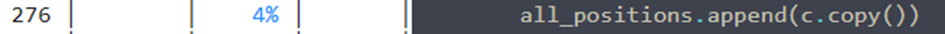

In der Simulation mit zehn Bällen wurden die Funktionen `will_collide` und `get_all_collisions` als die rechenintensivsten Teile des Codes identifiziert. Beide Funktionen berechnen den Abstand zwischen zwei Bällen mithilfe von `np.linalg.norm`, was sich als der rechenaufwändigste Teil dieser Funktionen herausstellte:
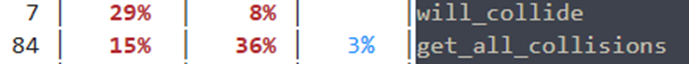

`np.linalg.norm` in `will_collide`: 

`np.linalg.norm` in `get_all_collisions`: 

Dies lässt sich dadurch erklären, dass `np.linalg.norm` bereits für sich genommen eine relativ kostspielige Operation ist, da sie die Subtraktion zweier Vektoren, das Quadrieren ihrer Komponenten, die Summation und schließlich die Quadratwurzel umfasst – alles Schritte, die zur Rechenintensität beitragen.

Darüber hinaus werden beide Funktionen in einer verschachtelten `for`-Schleife sehr häufig aufgerufen – im Prinzip für nahezu alle Ballpaare in jedem Zeitschritt, also etwa $≈\tfrac{N^2}{2}$ Mal (wobei $N$ die Anzahl der Bälle ist). Zusätzlich hat die Funktion will_collide eine eigene Schleife über das Array `k_values = [0, 0.25, 0.5, 0.75]`, was bedeutet, dass `np.linalg.norm` pro Zeitschritt vier weitere Male aufgerufen wird – also insgesamt etwa $≈4 \cdot \tfrac{N^2}{2}$ Aufrufe.

Für die Simulation mit zehn Bällen wird die Abstandsberechnung in `get_all_collisions` jedoch häufiger ausgeführt als in `will_collide`, da `get_all_collisions` wird schon dann ausgeführt, wenn die Bälle nicht maskiert sind. Die Funktion `will_collide` hingegen wird nur dann aufgerufen, wenn die Bälle nicht maskiert sind *und* sich darüber hinaus hinreichend annähern (näher als das Vierfache der Summe ihrer Radien). Erst wenn beide Bedingungen erfüllt sind, wird `will_collide` aufgerufen. Bei nur zehn Bällen ist die Anzahl möglicher Kollisionen noch zu gering, so dass die Iteration über `k_values` noch keine dominierende Rolle hat. Daher ist der Rechenaufwand von `get_all_collisions` in diesem Fall noch vergleichbar mit dem von `will_collide`.

Die Situation ändert sich drastisch bei einer Simulation mit 300 Bällen. Die höhere Anzahl an Bällen führt dazu, dass der Rechenaufwand beider Funktionen quadratisch skaliert. Gleichzeitig kommt es zu wesentlich mehr potenziellen Kollisionen (da sich mehr Bälle im selben Raum befinden), wodurch `will_collide` nahezu genauso häufig aufgerufen wird wie `get_all_collisions`. Aufgrund der zusätzlichen Schleife über `k_values` wird `will_collide` schließlich zur rechenintensivsten Funktion des gesamten Codes:

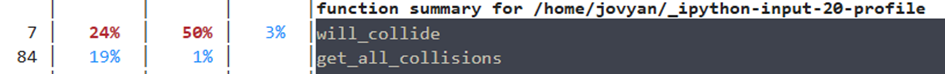

`np.linalg.norm` in `will_collide`: 

`np.linalg.norm` in `get_all_collisions`: 

Sie wird so dominant, dass der zuvor in der kollisionsfreien Simulation teuerste Codeabschnitt – das Speichern der Daten für die Visualisierung – keinen nennenswerten Anteil an den benötigten Rechenressourcen mehr hat:

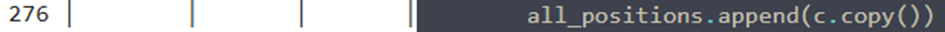

In [ ]:
c, v, m, mask = init(10)

In [ ]:
%%scalene --cpu-sampling-rate 0.01
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter


def will_collide(c1, c2, v1, v2, r1, r2, dt):
    """
    Prüft, ob zwei Bälle sich innerhalb eines Zeitschritts dt kollidieren werden

    Parameter:
    - c1, c2:   Positionen von Ball 1 und 2 
    - v1, v2:   Geschwindigkeiten von Ball 1 und 2
    - r1, r2:   Radien von Ball 1 und 2
    - dt:       Zeitschritt

    Rückgabewerte:
    - collided:                 Status: Ob eine Kollision erkannt wurde      
    - k_frac:                   Fraktion des Zeitschritts, bei dem die Kollision stattfindet
    - c1_before, c2_before:     Positionen von Ball 1 und 2 vor der Kollision
    """

    # Vorinitialisierung
    collided = False
    k_frac = 0
    c1_before = c1
    c2_before = c2
    k_values = [0, 0.25, 0.5, 0.75]  # Zeitanteile innerhalb des Zeitschritts

    for k in k_values:
        # Positionen der Bälle nach k * dt
        c1_pos = c1 + k * dt * v1
        c2_pos = c2 + k * dt * v2

        # Berechnung des Abstands zwischen den Bällen nach jedem k
        distance = np.linalg.norm(c1_pos - c2_pos)

        # Wenn Abstand kleiner als die Summe der Radien beider Bälle ist -> Kollision
        if distance < (r1 + r2):
            # Aktualisierung der Werte
            collided = True
            k_frac = k
            c1_before = c1_pos
            c2_before = c2_pos
            break  # Kollision gefunden -> Abbruch der Schleife

    return collided, k_frac, c1_before, c2_before



def collision(c1, c2, v1, v2, m1, m2):
    """
    Berechnet die elastische Kollision zwischen den Bällen 1 und 2
    
    Parameter:
    - c1, c2:   Positionen von Ball 1 und 2 
    - v1, v2:   Geschwindigkeiten von Ball 1 und 2
    - r1, r2:   Radien von Ball 1 und 2
    - m1, m2:   Massen von Ball 1 und 2
    
    Rückgabewerte:
    - v1_new, v2_new:   Neue Geschwindigkeiten von Ball 1 und 2 nach Kollision
    """
    
    # Abstand zwischen den Bällen
    r = c1 - c2
    norm_r = np.linalg.norm(r)  # Betrag des Abstandvektors
    
    # Skalarprodukt der Geschwindigkeitsdifferenz und des Positionsvektors
    v_diff = v1 - v2
    scalar_product = np.dot(v_diff, r)
    
    # Faktor für die Geschwindigkeitsänderung
    factor1 = (2 * m2) / (m1 + m2) * (scalar_product / norm_r**2)
    factor2 = (2 * m1) / (m1 + m2) * (scalar_product / norm_r**2)
    
    # Neue Geschwindigkeiten nach Kollision
    v1_new = (v1 - factor1 * r)
    v2_new = (v2 + factor2 * r)
    
    return v1_new, v2_new


def get_all_collisions(c, v, m, r, dt, mask, cooldown_frames = 4):
    """
    Prüft und behandelt alle möglichen Kollisionen zwischen Bällen
    
    Parameter:
    - c:                aktuelle Positionen von allen Bällen (Array der Form [N, 2])
    - v:                aktuelle Geschwindigkeiten von allen Bällen (Array der Form [N, 2])
    - m:                aktuelle Massen von allen Bällen (Array der Form [N, 2])
    - r:                aktuelle Radien von allen Bällen (Array der Form [N, 2])
    - dt:               Zeitschritt
    - mask:             Maske, die verhindert, dass Bälle nicht in mehreren (=cooldown_frames)  
                        aufeinanderfolgenden Zeitschritten miteinander kollidieren können
    - colldown_frames:  Anzahl der Zeitschritte, bis die Bälle nach einer Kollision
                        wieder für die Berechnung der nächsten Kollision berücksichtigt werden können
    
    Rückgabewerte:
    - c:    Neue Positionen der Bälle nach Kollisionen
    - v:    Neue Geschwindigkeiten der Bälle nach Kollisionen
    - mask: Aktualisierte Maske
    """
    
    N = len(c) # Anzahl der Bälle

    for i in range(N):
        for j in range(i + 1, N):
            
            # Prüfe, ob die Bälle maskiert sind
            if mask[i, j] > 0:
                continue  # Maske anwenden -> Kollision wird nicht überprüft

            # Prüfe, ob die Bälle nah genug sind
            distance = np.linalg.norm(c[i] - c[j])
            min_dist = r[i] + r[j]
            if distance >= 4 * min_dist:
                continue  # Bälle sind noch zu weit voneinander -> Kollision wird nicht überprüft
            
            # Prüfe ob die Kollision schon in diesem Zeitschritt stattfindet
            collided, k_frac, c1_before, c2_before = will_collide(c[i], c[j], v[i], v[j], r[i], r[j], dt)

            if collided:
                # Wenn Kollision, dann neue Geschwindigkeiten
                v1_new, v2_new = collision(c[i], c[j], v[i], v[j], m[i], m[j])
      
                # Neue Position nach der Kollision berechnen 
                c[i] = c1_before + v1_new * (1 - k_frac) * dt # neue Position für Ball 1
                c[j] = c2_before + v2_new * (1 - k_frac) * dt # neue Position für Ball 2
                
                # Aktualisierung von v 
                v[i] = v1_new
                v[j] = v2_new
                
                # Aktualisierung der Maske, wenn Kollisionen aufgetreten sind
                mask[i, j] = cooldown_frames
                mask[j, i] = cooldown_frames                
    
    # Aktualisierung der Maske, wenn keine Kollisionen aufgetreten sind
    mask = np.maximum(mask - 1, 0)
    
    return c, v, mask


def timestep_with_collisions(c, v, m, dt, g, r, xmax, ymax, mask):
    """
    Führt einen vollständigen Zeitschritt mit Kollisionen durch
    
    Parameter:
    - c:                aktuelle Positionen von allen Bällen (Array der Form [N, 2])
    - v:                aktuelle Geschwindigkeiten von allen Bällen (Array der Form [N, 2])
    - m:                aktuelle Massen von allen Bällen (Array der Form [N, 2])
    - dt:               Zeitschritt
    - g:                Gravitationsvektor
    - r:                aktuelle Radien von allen Bällen (Array der Form [N, 2])
    - xmax, ymax:       Begrenzung des Simulationsraums
    - mask:             Maske, die verhindert, dass Bälle nicht in mehreren (=cooldown_frames)  
                        aufeinanderfolgenden Zeitschritten miteinander kollidieren können

    
    Rückgabewerte:
    - c:    Neue Positionen der Bälle nach dt
    - v:    Neue Geschwindigkeiten der Bälle nach dt
    - mask: Aktualisierte Maske
    """
    
    # Gravitation anwenden
    v = v + g * dt
    c += v * dt

    # Kollisionen zwischen Bällen berechnen
    c, v, mask = get_all_collisions(c, v, m, r, dt, mask)

    # Wandkollisionen behandeln (links/rechts)
    left_wall = c[:, 0] <= 0 
    right_wall = c[:, 0] >= xmax 
    if np.any(left_wall | right_wall):
        dt2_left_wall = abs(c[left_wall, 0]) / abs(v[left_wall, 0]) 
        dt2_right_wall = (abs(c[right_wall,0]) - xmax) / abs(v[right_wall, 0]) 
        v[left_wall | right_wall, 0] *= -1 
        c[left_wall, 0] = dt2_left_wall * v[left_wall, 0] 
        c[right_wall, 0] = xmax - dt2_right_wall * v[right_wall, 0] 
    # Wandkollisionen (oben/unten)
    bottom = c[:, 1] <= 0
    top = c[:, 1] >= ymax
    if np.any(bottom | top):
        dt2_bottom = abs(c[bottom, 1]) / abs(v[bottom, 1])
        dt2_top = (abs(c[top, 1]) - ymax) / abs(v[top, 1])
        v[bottom | top, 1] *= -1
        c[bottom, 1] = dt2_bottom * v[bottom, 1]
        c[top, 1] = ymax - dt2_top * v[top, 1]

    return c, v, mask


# Erstellt eine animierte Visualisierung der Positionen
def animate_positions(all_positions, num_balls, xmax, ymax, r, m, filename="multi_ball_collisions.gif"):
    import matplotlib.pyplot as plt
    from matplotlib.animation import FuncAnimation, PillowWriter
    from matplotlib.patches import Circle
    import numpy as np

    print ("GIF wird erstellt...")
    colors = plt.cm.jet(np.linspace(0, 1, num_balls))

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_xlim(0, xmax)
    ax.set_ylim(0, ymax)
    ax.set_aspect('equal')
    ax.set_title("Simulation: Springende Bälle mit Kollisionen")

    # Bälle erstellen
    circles = []
    for i in range(num_balls):
        circle = Circle((0, 0), r[i], color=colors[i])
        ax.add_patch(circle)
        circles.append(circle)

    def init():
        for circle in circles:
            circle.center = (-10, -10) # Anfangs außerhalb des Bildes
        return circles

    def update(frame):
        positions = all_positions[frame]
        for i, circle in enumerate(circles):
            circle.center = positions[i]
        return circles

    ani = FuncAnimation(fig, update, frames=len(all_positions), init_func=init, blit=True, interval=50)
    ani.save(filename, writer=PillowWriter(fps=20))
    print(f"GIF gespeichert als: {filename}")

    
# Anfangsbedingungen
g = np.array([0, -9.81], dtype=np.float64)
xmax = 100
ymax = 100
steps = 1000
# dt = xmax * 1e-5
dt = 0.1

# Anzahl Bälle
N = 10

rng = np.random.default_rng(seed=123)

# Flag zur Aktivierung der Visualisierung (Trennung der Simulation und Visualisierung)
visualize = True

# Startpositionen
def init(n=N):
    c = xmax * rng.random((N, 2))
    # Startgeschwindigkeiten, max.
    v = np.array([xmax/10, ymax/10]) * rng.random((N, 2))
    # Masse
    m = rng.uniform(5, 15, size=N)
    r = np.sqrt(m) 
    mask = np.full((N, N), 0, np.int32)
    return c, v, m, r, mask

    
# ------------------------------
# HAUPTFUNKTION
# ------------------------------   

# Initialisierung 
# c, v, m, r, mask = init()

if visualize == True:
    # Führe Simulation mit Visualisierung durch und animiere das Ergebnis
    all_positions = [c.copy()]

    for i in range(steps):
        c, v, mask = timestep_with_collisions(c, v, m, dt, g, r, xmax, ymax, mask)
        all_positions.append(c.copy())
    print("Simulation (mit Visualisierung) war erfolgreich")
else:
    # Nur reine Simulation ohne Visualisierung
    for i in range(steps):
        timestep_with_collisions(c, v, m, dt, g, r, xmax, ymax, mask)
    print("Simulation (ohne Visualisierung) war erfolgreich")

In [20]:
c, v, m, r, mask = init(300)

In [ ]:
%%scalene --cpu-sampling-rate 0.01
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter


def will_collide(c1, c2, v1, v2, r1, r2, dt):
    """
    Prüft, ob zwei Bälle sich innerhalb eines Zeitschritts dt kollidieren werden

    Parameter:
    - c1, c2:   Positionen von Ball 1 und 2 
    - v1, v2:   Geschwindigkeiten von Ball 1 und 2
    - r1, r2:   Radien von Ball 1 und 2
    - dt:       Zeitschritt

    Rückgabewerte:
    - collided:                 Status: Ob eine Kollision erkannt wurde      
    - k_frac:                   Fraktion des Zeitschritts, bei dem die Kollision stattfindet
    - c1_before, c2_before:     Positionen von Ball 1 und 2 vor der Kollision
    """

    # Vorinitialisierung
    collided = False
    k_frac = 0
    c1_before = c1
    c2_before = c2
    k_values = [0, 0.25, 0.5, 0.75]  # Zeitanteile innerhalb des Zeitschritts

    for k in k_values:
        # Positionen der Bälle nach k * dt
        c1_pos = c1 + k * dt * v1
        c2_pos = c2 + k * dt * v2

        # Berechnung des Abstands zwischen den Bällen nach jedem k
        distance = np.linalg.norm(c1_pos - c2_pos)

        # Wenn Abstand kleiner als die Summe der Radien beider Bälle ist -> Kollision
        if distance < (r1 + r2):
            # Aktualisierung der Werte
            collided = True
            k_frac = k
            c1_before = c1_pos
            c2_before = c2_pos
            break  # Kollision gefunden -> Abbruch der Schleife

    return collided, k_frac, c1_before, c2_before



def collision(c1, c2, v1, v2, m1, m2):
    """
    Berechnet die elastische Kollision zwischen den Bällen 1 und 2
    
    Parameter:
    - c1, c2:   Positionen von Ball 1 und 2 
    - v1, v2:   Geschwindigkeiten von Ball 1 und 2
    - r1, r2:   Radien von Ball 1 und 2
    - m1, m2:   Massen von Ball 1 und 2
    
    Rückgabewerte:
    - v1_new, v2_new:   Neue Geschwindigkeiten von Ball 1 und 2 nach Kollision
    """
    
    # Abstand zwischen den Bällen
    r = c1 - c2
    norm_r = np.linalg.norm(r)  # Betrag des Abstandvektors
    
    # Skalarprodukt der Geschwindigkeitsdifferenz und des Positionsvektors
    v_diff = v1 - v2
    scalar_product = np.dot(v_diff, r)
    
    # Faktor für die Geschwindigkeitsänderung
    factor1 = (2 * m2) / (m1 + m2) * (scalar_product / norm_r**2)
    factor2 = (2 * m1) / (m1 + m2) * (scalar_product / norm_r**2)
    
    # Neue Geschwindigkeiten nach Kollision
    v1_new = (v1 - factor1 * r)
    v2_new = (v2 + factor2 * r)
    
    return v1_new, v2_new


def get_all_collisions(c, v, m, r, dt, mask, cooldown_frames = 4):
    """
    Prüft und behandelt alle möglichen Kollisionen zwischen Bällen
    
    Parameter:
    - c:                aktuelle Positionen von allen Bällen (Array der Form [N, 2])
    - v:                aktuelle Geschwindigkeiten von allen Bällen (Array der Form [N, 2])
    - m:                aktuelle Massen von allen Bällen (Array der Form [N, 2])
    - r:                aktuelle Radien von allen Bällen (Array der Form [N, 2])
    - dt:               Zeitschritt
    - mask:             Maske, die verhindert, dass Bälle nicht in mehreren (=cooldown_frames)  
                        aufeinanderfolgenden Zeitschritten miteinander kollidieren können
    - colldown_frames:  Anzahl der Zeitschritte, bis die Bälle nach einer Kollision
                        wieder für die Berechnung der nächsten Kollision berücksichtigt werden können
    
    Rückgabewerte:
    - c:    Neue Positionen der Bälle nach Kollisionen
    - v:    Neue Geschwindigkeiten der Bälle nach Kollisionen
    - mask: Aktualisierte Maske
    """
    
    N = len(c) # Anzahl der Bälle

    for i in range(N):
        for j in range(i + 1, N):
            
            # Prüfe, ob die Bälle maskiert sind
            if mask[i, j] > 0:
                continue  # Maske anwenden -> Kollision wird nicht überprüft

            # Prüfe, ob die Bälle nah genug sind
            distance = np.linalg.norm(c[i] - c[j])
            min_dist = r[i] + r[j]
            if distance >= 4 * min_dist:
                continue  # Bälle sind noch zu weit voneinander -> Kollision wird nicht überprüft
            
            # Prüfe ob die Kollision schon in diesem Zeitschritt stattfindet
            collided, k_frac, c1_before, c2_before = will_collide(c[i], c[j], v[i], v[j], r[i], r[j], dt)

            if collided:
                # Wenn Kollision, dann neue Geschwindigkeiten
                v1_new, v2_new = collision(c[i], c[j], v[i], v[j], m[i], m[j])
      
                # Neue Position nach der Kollision berechnen 
                c[i] = c1_before + v1_new * (1 - k_frac) * dt # neue Position für Ball 1
                c[j] = c2_before + v2_new * (1 - k_frac) * dt # neue Position für Ball 2
                
                # Aktualisierung von v 
                v[i] = v1_new
                v[j] = v2_new
                
                # Aktualisierung der Maske, wenn Kollisionen aufgetreten sind
                mask[i, j] = cooldown_frames
                mask[j, i] = cooldown_frames                
    
    # Aktualisierung der Maske, wenn keine Kollisionen aufgetreten sind
    mask = np.maximum(mask - 1, 0)
    
    return c, v, mask


def timestep_with_collisions(c, v, m, dt, g, r, xmax, ymax, mask):
    """
    Führt einen vollständigen Zeitschritt mit Kollisionen durch
    
    Parameter:
    - c:                aktuelle Positionen von allen Bällen (Array der Form [N, 2])
    - v:                aktuelle Geschwindigkeiten von allen Bällen (Array der Form [N, 2])
    - m:                aktuelle Massen von allen Bällen (Array der Form [N, 2])
    - dt:               Zeitschritt
    - g:                Gravitationsvektor
    - r:                aktuelle Radien von allen Bällen (Array der Form [N, 2])
    - xmax, ymax:       Begrenzung des Simulationsraums
    - mask:             Maske, die verhindert, dass Bälle nicht in mehreren (=cooldown_frames)  
                        aufeinanderfolgenden Zeitschritten miteinander kollidieren können

    
    Rückgabewerte:
    - c:    Neue Positionen der Bälle nach dt
    - v:    Neue Geschwindigkeiten der Bälle nach dt
    - mask: Aktualisierte Maske
    """
    
    # Gravitation anwenden
    v = v + g * dt
    c += v * dt

    # Kollisionen zwischen Bällen berechnen
    c, v, mask = get_all_collisions(c, v, m, r, dt, mask)

    # Wandkollisionen behandeln (links/rechts)
    left_wall = c[:, 0] <= 0 
    right_wall = c[:, 0] >= xmax 
    if np.any(left_wall | right_wall):
        dt2_left_wall = abs(c[left_wall, 0]) / abs(v[left_wall, 0]) 
        dt2_right_wall = (abs(c[right_wall,0]) - xmax) / abs(v[right_wall, 0]) 
        v[left_wall | right_wall, 0] *= -1 
        c[left_wall, 0] = dt2_left_wall * v[left_wall, 0] 
        c[right_wall, 0] = xmax - dt2_right_wall * v[right_wall, 0] 
    # Wandkollisionen (oben/unten)
    bottom = c[:, 1] <= 0
    top = c[:, 1] >= ymax
    if np.any(bottom | top):
        dt2_bottom = abs(c[bottom, 1]) / abs(v[bottom, 1])
        dt2_top = (abs(c[top, 1]) - ymax) / abs(v[top, 1])
        v[bottom | top, 1] *= -1
        c[bottom, 1] = dt2_bottom * v[bottom, 1]
        c[top, 1] = ymax - dt2_top * v[top, 1]

    return c, v, mask


# Erstellt eine animierte Visualisierung der Positionen
def animate_positions(all_positions, num_balls, xmax, ymax, r, m, filename="multi_ball_collisions.gif"):
    import matplotlib.pyplot as plt
    from matplotlib.animation import FuncAnimation, PillowWriter
    from matplotlib.patches import Circle
    import numpy as np

    print ("GIF wird erstellt...")
    colors = plt.cm.jet(np.linspace(0, 1, num_balls))

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_xlim(0, xmax)
    ax.set_ylim(0, ymax)
    ax.set_aspect('equal')
    ax.set_title("Simulation: Springende Bälle mit Kollisionen")

    # Bälle erstellen
    circles = []
    for i in range(num_balls):
        circle = Circle((0, 0), r[i], color=colors[i])
        ax.add_patch(circle)
        circles.append(circle)

    def init():
        for circle in circles:
            circle.center = (-10, -10) # Anfangs außerhalb des Bildes
        return circles

    def update(frame):
        positions = all_positions[frame]
        for i, circle in enumerate(circles):
            circle.center = positions[i]
        return circles

    ani = FuncAnimation(fig, update, frames=len(all_positions), init_func=init, blit=True, interval=50)
    ani.save(filename, writer=PillowWriter(fps=20))
    print(f"GIF gespeichert als: {filename}")

    
# Anfangsbedingungen
g = np.array([0, -9.81], dtype=np.float64)
xmax = 100
ymax = 100
steps = 1000
# dt = xmax * 1e-5
dt = 0.1

# Anzahl Bälle
N = 10

rng = np.random.default_rng(seed=123)

# Flag zur Aktivierung der Visualisierung (Trennung der Simulation und Visualisierung)
visualize = True

# Startpositionen
def init(n=N):
    c = xmax * rng.random((N, 2))
    # Startgeschwindigkeiten, max.
    v = np.array([xmax/10, ymax/10]) * rng.random((N, 2))
    # Masse
    m = rng.uniform(5, 15, size=N)
    r = np.sqrt(m) 
    mask = np.full((N, N), 0, np.int32)
    return c, v, m, r, mask

    
# ------------------------------
# HAUPTFUNKTION
# ------------------------------   

# Initialisierung 
# c, v, m, r, mask = init()

if visualize == True:
    # Führe Simulation mit Visualisierung durch und animiere das Ergebnis
    all_positions = [c.copy()]

    for i in range(steps):
        c, v, mask = timestep_with_collisions(c, v, m, dt, g, r, xmax, ymax, mask)
        all_positions.append(c.copy())
    print("Simulation (mit Visualisierung) war erfolgreich")
else:
    # Nur reine Simulation ohne Visualisierung
    for i in range(steps):
        timestep_with_collisions(c, v, m, dt, g, r, xmax, ymax, mask)
    print("Simulation (ohne Visualisierung) war erfolgreich")

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

**Aufgabe:** Versuchen Sie Ihren Code (d.h. `timestep_with_collisions`) zu optimieren, damit er besser skaliert.

Vergleichen Sie danach die Ausführungszeiten beider Varianten für 20 Zeitschritte mit $[100, 200,300]$ Bällen.

Stellen Sie den Vergleich graphisch dar.

_Points:_ 10

In [ ]:
%%scalene --cpu-sampling-rate 0.01
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter


def will_collide(c1, c2, v1, v2, r1, r2, dt):
    """
    Prüft, ob zwei Bälle sich innerhalb eines Zeitschritts dt kollidieren werden

    Parameter:
    - c1, c2:   Positionen von Ball 1 und 2 
    - v1, v2:   Geschwindigkeiten von Ball 1 und 2
    - r1, r2:   Radien von Ball 1 und 2
    - dt:       Zeitschritt

    Rückgabewerte:
    - collided:                 Status: Ob eine Kollision erkannt wurde      
    - k_frac:                   Fraktion des Zeitschritts, bei dem die Kollision stattfindet
    - c1_before, c2_before:     Positionen von Ball 1 und 2 vor der Kollision
    """

    # Vorinitialisierung
    collided = False
    k_frac = 0
    c1_before = c1
    c2_before = c2
    k_values = [0, 0.25, 0.5, 0.75]  # Zeitanteile innerhalb des Zeitschritts

    for k in k_values:
        # Positionen der Bälle nach k * dt
        c1_pos = c1 + k * dt * v1
        c2_pos = c2 + k * dt * v2

        # Berechnung des Abstands zwischen den Bällen nach jedem k
        distance = np.linalg.norm(c1_pos - c2_pos)

        # Wenn Abstand kleiner als die Summe der Radien beider Bälle ist -> Kollision
        if distance < (r1 + r2):
            # Aktualisierung der Werte
            collided = True
            k_frac = k
            c1_before = c1_pos
            c2_before = c2_pos
            break  # Kollision gefunden -> Abbruch der Schleife

    return collided, k_frac, c1_before, c2_before



def collision(c1, c2, v1, v2, m1, m2):
    """
    Berechnet die elastische Kollision zwischen den Bällen 1 und 2
    
    Parameter:
    - c1, c2:   Positionen von Ball 1 und 2 
    - v1, v2:   Geschwindigkeiten von Ball 1 und 2
    - r1, r2:   Radien von Ball 1 und 2
    - m1, m2:   Massen von Ball 1 und 2
    
    Rückgabewerte:
    - v1_new, v2_new:   Neue Geschwindigkeiten von Ball 1 und 2 nach Kollision
    """
    
    # Abstand zwischen den Bällen
    r = c1 - c2
    norm_r = np.linalg.norm(r)  # Betrag des Abstandvektors
    
    # Skalarprodukt der Geschwindigkeitsdifferenz und des Positionsvektors
    v_diff = v1 - v2
    scalar_product = np.dot(v_diff, r)
    
    # Faktor für die Geschwindigkeitsänderung
    factor1 = (2 * m2) / (m1 + m2) * (scalar_product / norm_r**2)
    factor2 = (2 * m1) / (m1 + m2) * (scalar_product / norm_r**2)
    
    # Neue Geschwindigkeiten nach Kollision
    v1_new = (v1 - factor1 * r)
    v2_new = (v2 + factor2 * r)
    
    return v1_new, v2_new


def get_all_collisions(c, v, m, r, dt, mask, cooldown_frames = 4):
    """
    Prüft und behandelt alle möglichen Kollisionen zwischen Bällen
    
    Parameter:
    - c:                aktuelle Positionen von allen Bällen (Array der Form [N, 2])
    - v:                aktuelle Geschwindigkeiten von allen Bällen (Array der Form [N, 2])
    - m:                aktuelle Massen von allen Bällen (Array der Form [N, 2])
    - r:                aktuelle Radien von allen Bällen (Array der Form [N, 2])
    - dt:               Zeitschritt
    - mask:             Maske, die verhindert, dass Bälle nicht in mehreren (=cooldown_frames)  
                        aufeinanderfolgenden Zeitschritten miteinander kollidieren können
    - colldown_frames:  Anzahl der Zeitschritte, bis die Bälle nach einer Kollision
                        wieder für die Berechnung der nächsten Kollision berücksichtigt werden können
    
    Rückgabewerte:
    - c:    Neue Positionen der Bälle nach Kollisionen
    - v:    Neue Geschwindigkeiten der Bälle nach Kollisionen
    - mask: Aktualisierte Maske
    """
    
    N = len(c) # Anzahl der Bälle

    for i in range(N):
        for j in range(i + 1, N):
            
            # Prüfe, ob die Bälle maskiert sind
            if mask[i, j] > 0:
                continue  # Maske anwenden -> Kollision wird nicht überprüft

            # Prüfe, ob die Bälle nah genug sind
            distance = np.linalg.norm(c[i] - c[j])
            min_dist = r[i] + r[j]
            if distance >= 4 * min_dist:
                continue  # Bälle sind noch zu weit voneinander -> Kollision wird nicht überprüft
            
            # Prüfe ob die Kollision schon in diesem Zeitschritt stattfindet
            collided, k_frac, c1_before, c2_before = will_collide(c[i], c[j], v[i], v[j], r[i], r[j], dt)

            if collided:
                # Wenn Kollision, dann neue Geschwindigkeiten
                v1_new, v2_new = collision(c[i], c[j], v[i], v[j], m[i], m[j])
      
                # Neue Position nach der Kollision berechnen 
                c[i] = c1_before + v1_new * (1 - k_frac) * dt # neue Position für Ball 1
                c[j] = c2_before + v2_new * (1 - k_frac) * dt # neue Position für Ball 2
                
                # Aktualisierung von v 
                v[i] = v1_new
                v[j] = v2_new
                
                # Aktualisierung der Maske, wenn Kollisionen aufgetreten sind
                mask[i, j] = cooldown_frames
                mask[j, i] = cooldown_frames                
    
    # Aktualisierung der Maske, wenn keine Kollisionen aufgetreten sind
    mask = np.maximum(mask - 1, 0)
    
    return c, v, mask


def timestep_with_collisions(c, v, m, dt, g, r, xmax, ymax, mask):
    """
    Führt einen vollständigen Zeitschritt mit Kollisionen durch
    
    Parameter:
    - c:                aktuelle Positionen von allen Bällen (Array der Form [N, 2])
    - v:                aktuelle Geschwindigkeiten von allen Bällen (Array der Form [N, 2])
    - m:                aktuelle Massen von allen Bällen (Array der Form [N, 2])
    - dt:               Zeitschritt
    - g:                Gravitationsvektor
    - r:                aktuelle Radien von allen Bällen (Array der Form [N, 2])
    - xmax, ymax:       Begrenzung des Simulationsraums
    - mask:             Maske, die verhindert, dass Bälle nicht in mehreren (=cooldown_frames)  
                        aufeinanderfolgenden Zeitschritten miteinander kollidieren können

    
    Rückgabewerte:
    - c:    Neue Positionen der Bälle nach dt
    - v:    Neue Geschwindigkeiten der Bälle nach dt
    - mask: Aktualisierte Maske
    """
    
    # Gravitation anwenden
    v = v + g * dt
    c += v * dt

    # Kollisionen zwischen Bällen berechnen
    c, v, mask = get_all_collisions(c, v, m, r, dt, mask)

    # Wandkollisionen behandeln (links/rechts)
    left_wall = c[:, 0] <= 0 
    right_wall = c[:, 0] >= xmax 
    if np.any(left_wall | right_wall):
        dt2_left_wall = abs(c[left_wall, 0]) / abs(v[left_wall, 0]) 
        dt2_right_wall = (abs(c[right_wall,0]) - xmax) / abs(v[right_wall, 0]) 
        v[left_wall | right_wall, 0] *= -1 
        c[left_wall, 0] = dt2_left_wall * v[left_wall, 0] 
        c[right_wall, 0] = xmax - dt2_right_wall * v[right_wall, 0] 
    # Wandkollisionen (oben/unten)
    bottom = c[:, 1] <= 0
    top = c[:, 1] >= ymax
    if np.any(bottom | top):
        dt2_bottom = abs(c[bottom, 1]) / abs(v[bottom, 1])
        dt2_top = (abs(c[top, 1]) - ymax) / abs(v[top, 1])
        v[bottom | top, 1] *= -1
        c[bottom, 1] = dt2_bottom * v[bottom, 1]
        c[top, 1] = ymax - dt2_top * v[top, 1]

    return c, v, mask


# Erstellt eine animierte Visualisierung der Positionen
def animate_positions(all_positions, num_balls, xmax, ymax, r, m, filename="multi_ball_collisions.gif"):
    import matplotlib.pyplot as plt
    from matplotlib.animation import FuncAnimation, PillowWriter
    from matplotlib.patches import Circle
    import numpy as np

    print ("GIF wird erstellt...")
    colors = plt.cm.jet(np.linspace(0, 1, num_balls))

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_xlim(0, xmax)
    ax.set_ylim(0, ymax)
    ax.set_aspect('equal')
    ax.set_title("Simulation: Springende Bälle mit Kollisionen")

    # Bälle erstellen
    circles = []
    for i in range(num_balls):
        circle = Circle((0, 0), r[i], color=colors[i])
        ax.add_patch(circle)
        circles.append(circle)

    def init():
        for circle in circles:
            circle.center = (-10, -10) # Anfangs außerhalb des Bildes
        return circles

    def update(frame):
        positions = all_positions[frame]
        for i, circle in enumerate(circles):
            circle.center = positions[i]
        return circles

    ani = FuncAnimation(fig, update, frames=len(all_positions), init_func=init, blit=True, interval=50)
    ani.save(filename, writer=PillowWriter(fps=20))
    print(f"GIF gespeichert als: {filename}")

    
# Anfangsbedingungen
g = np.array([0, -9.81], dtype=np.float64)
xmax = 100
ymax = 100
steps = 1000
# dt = xmax * 1e-5
dt = 0.1

# Anzahl Bälle
N = 10

rng = np.random.default_rng(seed=123)

# Flag zur Aktivierung der Visualisierung (Trennung der Simulation und Visualisierung)
visualize = True

# Startpositionen
def init(n=N):
    c = xmax * rng.random((N, 2))
    # Startgeschwindigkeiten, max.
    v = np.array([xmax/10, ymax/10]) * rng.random((N, 2))
    # Masse
    m = rng.uniform(5, 15, size=N)
    r = np.sqrt(m) 
    mask = np.full((N, N), 0, np.int32)
    return c, v, m, r, mask

    
# ------------------------------
# HAUPTFUNKTION
# ------------------------------   

# Initialisierung 
# c, v, m, r, mask = init()

if visualize == True:
    # Führe Simulation mit Visualisierung durch und animiere das Ergebnis
    all_positions = [c.copy()]

    for i in range(steps):
        c, v, mask = timestep_with_collisions(c, v, m, dt, g, r, xmax, ymax, mask)
        all_positions.append(c.copy())
    print("Simulation (mit Visualisierung) war erfolgreich")
else:
    # Nur reine Simulation ohne Visualisierung
    for i in range(steps):
        timestep_with_collisions(c, v, m, dt, g, r, xmax, ymax, mask)
    print("Simulation (ohne Visualisierung) war erfolgreich")

In [20]:
c, v, m, r, mask = init(300)

In [ ]:
%%scalene --cpu-sampling-rate 0.01
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter


def will_collide(c1, c2, v1, v2, r1, r2, dt):
    """
    Prüft, ob zwei Bälle sich innerhalb eines Zeitschritts dt kollidieren werden

    Parameter:
    - c1, c2:   Positionen von Ball 1 und 2 
    - v1, v2:   Geschwindigkeiten von Ball 1 und 2
    - r1, r2:   Radien von Ball 1 und 2
    - dt:       Zeitschritt

    Rückgabewerte:
    - collided:                 Status: Ob eine Kollision erkannt wurde      
    - k_frac:                   Fraktion des Zeitschritts, bei dem die Kollision stattfindet
    - c1_before, c2_before:     Positionen von Ball 1 und 2 vor der Kollision
    """

    # Vorinitialisierung
    collided = False
    k_frac = 0
    c1_before = c1
    c2_before = c2
    k_values = [0, 0.25, 0.5, 0.75]  # Zeitanteile innerhalb des Zeitschritts

    for k in k_values:
        # Positionen der Bälle nach k * dt
        c1_pos = c1 + k * dt * v1
        c2_pos = c2 + k * dt * v2

        # Berechnung des Abstands zwischen den Bällen nach jedem k
        distance = np.linalg.norm(c1_pos - c2_pos)

        # Wenn Abstand kleiner als die Summe der Radien beider Bälle ist -> Kollision
        if distance < (r1 + r2):
            # Aktualisierung der Werte
            collided = True
            k_frac = k
            c1_before = c1_pos
            c2_before = c2_pos
            break  # Kollision gefunden -> Abbruch der Schleife

    return collided, k_frac, c1_before, c2_before



def collision(c1, c2, v1, v2, m1, m2):
    """
    Berechnet die elastische Kollision zwischen den Bällen 1 und 2
    
    Parameter:
    - c1, c2:   Positionen von Ball 1 und 2 
    - v1, v2:   Geschwindigkeiten von Ball 1 und 2
    - r1, r2:   Radien von Ball 1 und 2
    - m1, m2:   Massen von Ball 1 und 2
    
    Rückgabewerte:
    - v1_new, v2_new:   Neue Geschwindigkeiten von Ball 1 und 2 nach Kollision
    """
    
    # Abstand zwischen den Bällen
    r = c1 - c2
    norm_r = np.linalg.norm(r)  # Betrag des Abstandvektors
    
    # Skalarprodukt der Geschwindigkeitsdifferenz und des Positionsvektors
    v_diff = v1 - v2
    scalar_product = np.dot(v_diff, r)
    
    # Faktor für die Geschwindigkeitsänderung
    factor1 = (2 * m2) / (m1 + m2) * (scalar_product / norm_r**2)
    factor2 = (2 * m1) / (m1 + m2) * (scalar_product / norm_r**2)
    
    # Neue Geschwindigkeiten nach Kollision
    v1_new = (v1 - factor1 * r)
    v2_new = (v2 + factor2 * r)
    
    return v1_new, v2_new


def get_all_collisions(c, v, m, r, dt, mask, cooldown_frames = 4):
    """
    Prüft und behandelt alle möglichen Kollisionen zwischen Bällen
    
    Parameter:
    - c:                aktuelle Positionen von allen Bällen (Array der Form [N, 2])
    - v:                aktuelle Geschwindigkeiten von allen Bällen (Array der Form [N, 2])
    - m:                aktuelle Massen von allen Bällen (Array der Form [N, 2])
    - r:                aktuelle Radien von allen Bällen (Array der Form [N, 2])
    - dt:               Zeitschritt
    - mask:             Maske, die verhindert, dass Bälle nicht in mehreren (=cooldown_frames)  
                        aufeinanderfolgenden Zeitschritten miteinander kollidieren können
    - colldown_frames:  Anzahl der Zeitschritte, bis die Bälle nach einer Kollision
                        wieder für die Berechnung der nächsten Kollision berücksichtigt werden können
    
    Rückgabewerte:
    - c:    Neue Positionen der Bälle nach Kollisionen
    - v:    Neue Geschwindigkeiten der Bälle nach Kollisionen
    - mask: Aktualisierte Maske
    """
    
    N = len(c) # Anzahl der Bälle

    for i in range(N):
        for j in range(i + 1, N):
            
            # Prüfe, ob die Bälle maskiert sind
            if mask[i, j] > 0:
                continue  # Maske anwenden -> Kollision wird nicht überprüft

            # Prüfe, ob die Bälle nah genug sind
            distance = np.linalg.norm(c[i] - c[j])
            min_dist = r[i] + r[j]
            if distance >= 4 * min_dist:
                continue  # Bälle sind noch zu weit voneinander -> Kollision wird nicht überprüft
            
            # Prüfe ob die Kollision schon in diesem Zeitschritt stattfindet
            collided, k_frac, c1_before, c2_before = will_collide(c[i], c[j], v[i], v[j], r[i], r[j], dt)

            if collided:
                # Wenn Kollision, dann neue Geschwindigkeiten
                v1_new, v2_new = collision(c[i], c[j], v[i], v[j], m[i], m[j])
      
                # Neue Position nach der Kollision berechnen 
                c[i] = c1_before + v1_new * (1 - k_frac) * dt # neue Position für Ball 1
                c[j] = c2_before + v2_new * (1 - k_frac) * dt # neue Position für Ball 2
                
                # Aktualisierung von v 
                v[i] = v1_new
                v[j] = v2_new
                
                # Aktualisierung der Maske, wenn Kollisionen aufgetreten sind
                mask[i, j] = cooldown_frames
                mask[j, i] = cooldown_frames                
    
    # Aktualisierung der Maske, wenn keine Kollisionen aufgetreten sind
    mask = np.maximum(mask - 1, 0)
    
    return c, v, mask


def timestep_with_collisions(c, v, m, dt, g, r, xmax, ymax, mask):
    """
    Führt einen vollständigen Zeitschritt mit Kollisionen durch
    
    Parameter:
    - c:                aktuelle Positionen von allen Bällen (Array der Form [N, 2])
    - v:                aktuelle Geschwindigkeiten von allen Bällen (Array der Form [N, 2])
    - m:                aktuelle Massen von allen Bällen (Array der Form [N, 2])
    - dt:               Zeitschritt
    - g:                Gravitationsvektor
    - r:                aktuelle Radien von allen Bällen (Array der Form [N, 2])
    - xmax, ymax:       Begrenzung des Simulationsraums
    - mask:             Maske, die verhindert, dass Bälle nicht in mehreren (=cooldown_frames)  
                        aufeinanderfolgenden Zeitschritten miteinander kollidieren können

    
    Rückgabewerte:
    - c:    Neue Positionen der Bälle nach dt
    - v:    Neue Geschwindigkeiten der Bälle nach dt
    - mask: Aktualisierte Maske
    """
    
    # Gravitation anwenden
    v = v + g * dt
    c += v * dt

    # Kollisionen zwischen Bällen berechnen
    c, v, mask = get_all_collisions(c, v, m, r, dt, mask)

    # Wandkollisionen behandeln (links/rechts)
    left_wall = c[:, 0] <= 0 
    right_wall = c[:, 0] >= xmax 
    if np.any(left_wall | right_wall):
        dt2_left_wall = abs(c[left_wall, 0]) / abs(v[left_wall, 0]) 
        dt2_right_wall = (abs(c[right_wall,0]) - xmax) / abs(v[right_wall, 0]) 
        v[left_wall | right_wall, 0] *= -1 
        c[left_wall, 0] = dt2_left_wall * v[left_wall, 0] 
        c[right_wall, 0] = xmax - dt2_right_wall * v[right_wall, 0] 
    # Wandkollisionen (oben/unten)
    bottom = c[:, 1] <= 0
    top = c[:, 1] >= ymax
    if np.any(bottom | top):
        dt2_bottom = abs(c[bottom, 1]) / abs(v[bottom, 1])
        dt2_top = (abs(c[top, 1]) - ymax) / abs(v[top, 1])
        v[bottom | top, 1] *= -1
        c[bottom, 1] = dt2_bottom * v[bottom, 1]
        c[top, 1] = ymax - dt2_top * v[top, 1]

    return c, v, mask


# Erstellt eine animierte Visualisierung der Positionen
def animate_positions(all_positions, num_balls, xmax, ymax, r, m, filename="multi_ball_collisions.gif"):
    import matplotlib.pyplot as plt
    from matplotlib.animation import FuncAnimation, PillowWriter
    from matplotlib.patches import Circle
    import numpy as np

    print ("GIF wird erstellt...")
    colors = plt.cm.jet(np.linspace(0, 1, num_balls))

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_xlim(0, xmax)
    ax.set_ylim(0, ymax)
    ax.set_aspect('equal')
    ax.set_title("Simulation: Springende Bälle mit Kollisionen")

    # Bälle erstellen
    circles = []
    for i in range(num_balls):
        circle = Circle((0, 0), r[i], color=colors[i])
        ax.add_patch(circle)
        circles.append(circle)

    def init():
        for circle in circles:
            circle.center = (-10, -10) # Anfangs außerhalb des Bildes
        return circles

    def update(frame):
        positions = all_positions[frame]
        for i, circle in enumerate(circles):
            circle.center = positions[i]
        return circles

    ani = FuncAnimation(fig, update, frames=len(all_positions), init_func=init, blit=True, interval=50)
    ani.save(filename, writer=PillowWriter(fps=20))
    print(f"GIF gespeichert als: {filename}")

    
# Anfangsbedingungen
g = np.array([0, -9.81], dtype=np.float64)
xmax = 100
ymax = 100
steps = 1000
# dt = xmax * 1e-5
dt = 0.1

# Anzahl Bälle
N = 10

rng = np.random.default_rng(seed=123)

# Flag zur Aktivierung der Visualisierung (Trennung der Simulation und Visualisierung)
visualize = True

# Startpositionen
def init(n=N):
    c = xmax * rng.random((N, 2))
    # Startgeschwindigkeiten, max.
    v = np.array([xmax/10, ymax/10]) * rng.random((N, 2))
    # Masse
    m = rng.uniform(5, 15, size=N)
    r = np.sqrt(m) 
    mask = np.full((N, N), 0, np.int32)
    return c, v, m, r, mask

    
# ------------------------------
# HAUPTFUNKTION
# ------------------------------   

# Initialisierung 
# c, v, m, r, mask = init()

if visualize == True:
    # Führe Simulation mit Visualisierung durch und animiere das Ergebnis
    all_positions = [c.copy()]

    for i in range(steps):
        c, v, mask = timestep_with_collisions(c, v, m, dt, g, r, xmax, ymax, mask)
        all_positions.append(c.copy())
    print("Simulation (mit Visualisierung) war erfolgreich")
else:
    # Nur reine Simulation ohne Visualisierung
    for i in range(steps):
        timestep_with_collisions(c, v, m, dt, g, r, xmax, ymax, mask)
    print("Simulation (ohne Visualisierung) war erfolgreich")

<!-- END QUESTION -->

## Optimierung des Gauß-Verfahrens (30 Punkte)

<!-- BEGIN QUESTION -->

**Aufgabe:** Optimieren Sie die Funktionen `lu_decomposition` und `custom_solve` aus der zweiten Einsendeaufgabe mit Hilfe von Numba.

An welcher Stelle ist die Verwendung von `prange` richtig und sinnvoll? 

Vergleichen Sie die Performance vor und nach der Optimierung für Gleichungssysteme der Größe $256\times 256 $ und $512 \times 512$.

Stellen Sie den Vergleich graphisch dar.

_Points:_ 30

<span style="color: blue;">
  <h2>Python Funktionen vorbereiten</h2>
    
In der nächsten Zelle werden zunächst die benötigten Bibliotheken geladen:  
- `numpy` für grundlegende Array-Operationen  
- `numba` (mit `njit` und `prange`) zur Beschleunigung von Python-Schleifen  

Anschließend wird die aus EA1 bekannte Funktion **`b_solve`** definiert, die ein lineares Gleichungssystem \(Ax = b\) für eine obere Dreiecksmatrix \(A\) mittels Rückwärtssubstitution löst. 
    
Die Funktion wurde leicht abgewandelt indem sie nun nicht mehr numpys `np.dot` verwendet, mit welchem zuvor eine innere Schleife vermieden wurde.
Die inner Schleife wird hier gezielt wieder eingeführt um eine Parallelisierung mittels numbas `prange` zu ermöglichen. In den Funktionen **`l_solve`** und **`lu_decomposition`** wurde durch äquivalentes Vorgehen ebenfalls eine Parallelisierung der inneren Schleife ermöglicht. Es wird sich zeigen, dass `prange` nur sinnvoll in **`lu_decomposition`** ist.
    
Wichtig ist, dass die äußere Schleife nie parallel bearbeitet werden sollte, da in diesen Matrixoperationen Ergebnisse aus vorangegangenen Operationen als Parameter verwendet werden.
Solch eine Parallelisierung ist tatsächlich im Code implementierbar, was dann aber zu undefiniertem Verhalten und falschen Ergebnissen führt. 
<span>

In [10]:
import numpy as np
from numba import njit, prange

def b_solve(A, b):
    """Löst ein lineares Gleichungssystem Ax = b wobei A eine obere Dreiecksmatrix ist"""

    x = np.zeros_like(b, dtype=np.float64)  # Vektor für die Lösung, initialisiert mit Nullen    
    n = b.shape[0]
    
    # Rückwärtssubstitution
    for i in range(n - 1, -1, -1):                 
        #langsamer summation = np.dot(A[i, i + 1:], x[i + 1:]) # hier wird die Vektorisierung, die numpy zur Verfügung stellt, benutzt, um die Effizienz zu erhöhen
        #langsamer x[i] = (b[i] - summation) / A[i, i]  # Berechnung des aktuellen x[i]
        
        # Berechnung der Summe der Produkte der bekannten x-Werte 
        summation = b[i]
        for j in prange(i+1, n): # prange für parallel
            summation -= A[i, j] * x[j]
        x[i] = summation / A[i, i]        
    return x

def lu_decomposition(A):
    """L und U Matrix werden innerhalb von A Matrix berechnet und der Pivot-Vektor wird ausgegeben"""
    
    n = A.shape[0]
    P = np.arange(n)
    for k in range(n):
        
        # Pivotisierung: Index der Zeile mit größtem Betrag in Spalte k finden
        pivot_index = np.argmax(np.abs(A[k:n, k])) + k
        if A[pivot_index, k] == 0:
            raise ValueError("Matrix ist singulär.")
            
        # Zeilen tauschen in A
        if pivot_index != k:
            A[np.array([k, pivot_index]), :] = A[np.array([pivot_index, k]), :]
            P[np.array([k, pivot_index])] = P[np.array([pivot_index, k])]
        
        #langsamer A[k+1:n, k] /= A[k, k]    # Berechnung L unterhalb der Diagonale        
        #langsamer A[k+1:n, k+1:n] -= np.outer(A[k+1:n, k], A[k, k+1:n])    # Berechnung U obere Dreiecksmatrix inklusive Diagonale
            
        # Multiplikatoren berechnen
        v = A[k+1:n, k] / A[k, k]
        A[k+1:n, k] = v
        # Elimination im Rest der Matrix parallelisiert
        for i in prange(k+1, n):
            A[i, k+1:n] -= v[i - (k+1)] * A[k, k+1:n]

    return P #Pivot-Vektor

def l_solve(A, y):
    """Lösen von Ly = b[P] mit Vorwärtssubstitution. L ist untere Dreiecksmatrix mit Einheitsdiagonale"""
    
    # b[P] wird direkt als Parameter y übergeben und inplace berechnet
    n = y.shape[0]   
    # Vorwärtssubstitution
    for i in range(n):        
        # langsamer y[i] -= np.dot(A[i,:i], y[:i])
        summation = y[i]
        for j in prange(i):
            summation -= A[i, j] * y[j]
        y[i] = summation
    return y

def custom_solve(A, b):
    """Löst ein lineares Gleichungssystem Ax = b mittels LU-Zerlegung und gib Vektor x aus"""   
    
    A = A.astype(np.float64)    # Sicherstellen, dass mit floats gerechnet wird
    b = b.astype(np.float64)
    
    P = lu_decomposition(A)    # Pivot-Vektor und A (welches LU-Zerlegung enthält) werden berechnet   
    y = l_solve(A, b[P])    # Ly = b[P] wird gelöst für y     
    x = b_solve(A, y)    # Ux = y wird gelöst für x    
    return x

<span style="color: blue;">
  <h2>JIT‑Kompilierung und Parallelvarianten</h2>

In der nächsten Zelle werden alle zuvor definierten Python‑Funktionen mittels Numba JIT kompiliert, sodass sie in nativem Maschinencode ausgeführt werden können:

  
  - **Serielle JIT‑Versionen**  
    `b_solve_njit`, `lu_decomposition_njit` und `l_solve_njit` werden mit `njit` kompiliert.  

  
  - **Parallelisierte JIT‑Versionen**  
    `b_solve_njit_par`, `lu_decomposition_njit_par` und `l_solve_njit_par` nutzen `parallel=True` für Multi‑Core‑Execution.  

  
  - **Gesamtfunktionen**  
   - `cs_njit`: Führt LU‑Zerlegung, Vorwärts‑ und Rückwärtssubstitution vollständig in reinem Numba‑Code aus dank jit-Kompilierung.  
   - `cs_parallel_solve`: Verwendet zusätzlich zu njit parallele Vorwärts- und Rückwärtssubstitution aber serielle LU-Zerlegung
   - `cs_parallel_lu`: Verwendet zusätzlich zu njit parallele Ausführung der LU‑Zerlegung gefolgt von serieller Substitution.  
</span>


In [11]:
#njit Versionen aller python Funktionen
#njit steht für "No python objects Just In Time compilation"
b_solve_njit = njit(b_solve)
lu_decomposition_njit = njit(lu_decomposition)
l_solve_njit = njit(l_solve)   

#njit Versionen parallelisiert
b_solve_njit_par = njit(b_solve, parallel=True)
lu_decomposition_njit_par = njit(lu_decomposition, parallel=True)
l_solve_njit_par = njit(l_solve, parallel=True)


@njit
def cs_njit(A, b):
    """njit Version von custom_solve"""
    A = A.astype(np.float64)    # Sicherstellen, dass mit floats gerechnet wird
    b = b.astype(np.float64)
    
    P = lu_decomposition_njit(A)    # Pivot-Vektor und A (welches LU-Zerlegung enthält) werden berechnet   
    y = l_solve_njit(A, b[P])    # Ly = b[P] wird gelöst für y     
    x = b_solve_njit(A, y)    # Ux = y wird gelöst für x    
    return x

@njit
def cs_parallel_solve(A, b):
    """njit Version von custom_solve mit solve Funktionen parallel"""
    A = A.astype(np.float64)    # Sicherstellen, dass mit floats gerechnet wird
    b = b.astype(np.float64)
    
    P = lu_decomposition_njit(A)    # Pivot-Vektor und A (welches LU-Zerlegung enthält) werden berechnet   
    y = l_solve_njit_par(A, b[P])    # Ly = b[P] wird gelöst für y     
    x = b_solve_njit_par(A, y)    # Ux = y wird gelöst für x    
    return x

@njit
def cs_parallel_lu(A, b):
    """njit Version von custom_solve mit lu_decomposition parallel"""
    A = A.astype(np.float64)    # Sicherstellen, dass mit floats gerechnet wird
    b = b.astype(np.float64)
    
    P = lu_decomposition_njit_par(A)    # Pivot-Vektor und A (welches LU-Zerlegung enthält) werden berechnet   
    y = l_solve_njit(A, b[P])    # Ly = b[P] wird gelöst für y     
    x = b_solve_njit(A, y)    # Ux = y wird gelöst für x    
    return x

<span style="color: blue;">
  <h2>Messung der Laufzeiten</h2>

In der nächsten Zelle erfolgt ein systematischer Test der verschiedenen Lösungsvarianten:

  
  - **Modulimporte & Konfiguration**  
    Import von `scipy.linalg` und `perf_counter_ns` sowie Festlegung von `iterations` (Anzahl der Durchläufe), `dimensions` (Matrixgrößen) und  
    `function_variations` (Liste der Solve‑Funktionen: `cs_njit`, `cs_parallel_solve`, `cs_parallel_lu`, `custom_solve`).  

  
  - **Initialisierung der Laufzeitspeicher**  
    Ein Dictionary `run_times_dict` wird angelegt, um für jede Methode und Matrixdimension die kumulierten Laufzeiten zu erfassen.  

  
  - **Testschleifen**  
    Für jede Matrixgröße und jede Funktion wird eine belibiebige Matrix A erzeugt, die Lösung entsprechend der Methode berechnet, mit `linalg.solve` auf  
    Korrektheit geprüft (mittels `assert`) und die benötigte Zeit gemessen.  

  
  - **Ergebnisaggregation**  
    Die gemessenen Laufzeiten aller Iterationen werden summiert und in `run_times_dict` abgelegt, um später eine Performance‑Analyse durchzuführen.  
</span>


In [5]:
import scipy.linalg as linalg
from time import perf_counter_ns

# Vergleicht Ergebnisse von custom_solve mit linalg.solve mittels assert-Bedingung
# berechnet auch die Laufzeit

iterations = 20    # Anzahl der Wiederholungen
dimensions = [256, 512]    # Matrix A hat Dimension n x n 
function_variations = [cs_njit, cs_parallel_solve, cs_parallel_lu, custom_solve] # Funktionsvarianten von custom_solve 
run_times_dict = dict([(f.__name__, dict([(n,0.) for n in dimensions])) for f in function_variations])    # dict in dem die run_times gemessen werden

print(f"{"Funktionsvariante":<18} {"Dimension":<10} {"Ø-Laufzeit":<12}")
# unterschiedliche Funktions varianten werden variiert
for custom_solve_variation in function_variations:     
    _run_times = run_times_dict[custom_solve_variation.__name__] # run_times der aktuellen Funktion
    
    for n in dimensions: 
        rng = np.random.default_rng(seed=123)    # random seed für Reproduzierbarkeit
        A = rng.random((n, n))
        b = rng.random(n)   
        linalg_x = linalg.solve(A, b)    # Ergebniss von linalg.solve zum Prüfen der Korrektheit
        
        for run in range(iterations + 1):     # Funktionen wiederholen zum testen der Performance 
            start_ns = perf_counter_ns()     # Startzeitpunkt in ns
            custom_x = custom_solve_variation(A, b)
            if run > 0: # Durchlauf 0 compiliert und weicht von der Laufzeit stark ab 
                _run_times[n] += perf_counter_ns() - start_ns # Laufzeit wird in dict summiert    

        #sicherstellen, dass Ergebnisse gleich sind, float-Unpräzision ignorieren
        assert np.allclose(linalg_x, custom_x), f"Fehler bei Dimension {n} mit Funktion {custom_solve_variation.__name__}"  
        
        print(f"{custom_solve_variation.__name__:<18} {n:<10} {_run_times[n] / iterations / 1e6:.3f} ms")
    print()    # Leerzeile

Funktionsvariante  Dimension  Ø-Laufzeit  
cs_njit            256        3.276 ms
cs_njit            512        23.863 ms

cs_parallel_solve  256        7.513 ms
cs_parallel_solve  512        33.035 ms

cs_parallel_lu     256        5.588 ms
cs_parallel_lu     512        13.814 ms

custom_solve       256        53.718 ms
custom_solve       512        225.936 ms



In [14]:
%%timeit
custom_x = cs_njit(A, b)    # berechnete Laufzeit kann mit %%timeit line-magic verifiziert werden

23.6 ms ± 56.3 µs per loop (mean ± std. dev. of 7 runs, 1 loop each)


<span style="color: blue;">
  
  **Performance‑Vergleich (256×256):**   
    
  - **`cs_njit`:** 3,276 ms → ca. 16,4× schneller  
  - **`cs_parallel_lu`:** 5,588 ms → ca. 9,6× schneller  
  - **`cs_parallel_solve`:** 7,513 ms → ca. 7,1× schneller  
  - **Original `custom_solve`:** 53,718 ms  
  
  **Performance‑Vergleich (512×512):**  
   
  - **`cs_njit`:** 23,863 ms → ca. 9,5× schneller  
  - **`cs_parallel_lu`:** 13,814 ms → ca. 16,4× schneller  
  - **`cs_parallel_solve`:** 33,035 ms → ca. 6,8× schneller  
  - **Original `custom_solve`:** 225,936 ms  
  
  Numba verbessert die Laufzeit deutlich. Die Verwendung von `prange` lohnt sich nur für die innere Schleife der LU‑Zerlegung bei großen Matrizen.  
  Die Laufzeiten variieren wieder von System zu System.  
</span>



<span style="color: blue;">
  <h2>Visualisierung der Laufzeiten</h2>

In der nächsten Zelle werden die durchschnittlichen Laufzeiten aller Solve‑Varianten je Matrixdimension berechnet und als logarithmisches Balkendiagramm dargestellt:

  
  - **Berechnung der Durchschnittswerte**  
    Die in `run_times_dict` gesammelten Gesamtlaufzeiten werden durch `iterations` geteilt und von Nanosekunden in Millisekunden umgerechnet.  

  
  - **Erstellung des Balkendiagramms**  
    Für jede Funktion werden nebeneinanderstehende Balken gezeichnet. Die Variable `width` steuert die Breite, und die x‑Positionen werden entsprechend der Anzahl der Funktionen verschoben.  

  
  - **Logarithmische Skalierung**  
    Die y‑Achse ist mit `plt.yscale('log')` auf Log‑Skala eingestellt, um große Zeitunterschiede übersichtlich abzubilden.  

  
  - **Anpassung der Achsenbeschriftungen**  
    - x‑Ticks entsprechen den Matrixdimensionen (`dimensions`)  
    - y‑Ticks werden auf die Original‑Werte gesetzt und mit einer Nachkommastelle formatiert  

  
  - **Feinschliff**  
    Achsentitel, Diagrammtitel, Legende und Gitternetzlinien werden hinzugefügt; abschließend sorgt `plt.tight_layout()` für ein sauberes Layout.  
</span>


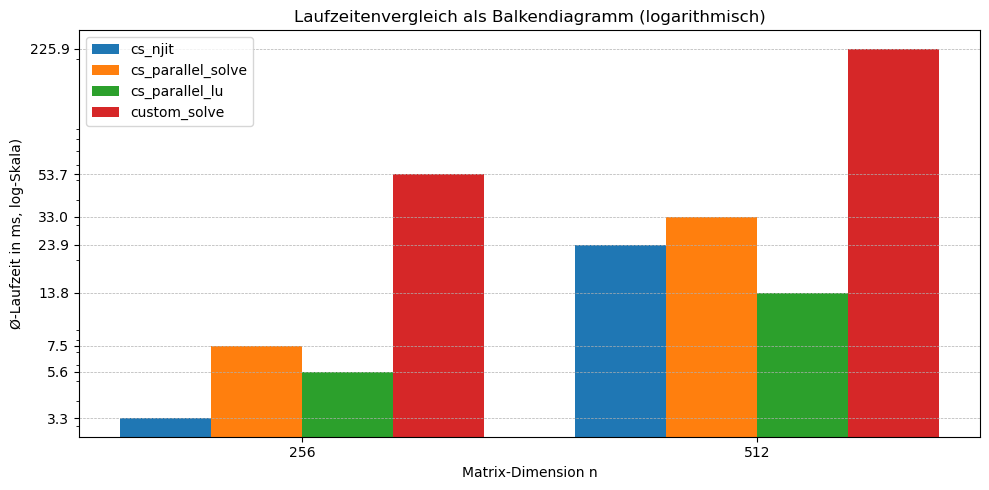

In [12]:
import matplotlib.pyplot as plt

# Berechnung der Durchschnittlichen Laufzeiten in ms pro Dimension
run_times_means = dict([(func, [v / iterations / 1e6 for v in run_times_dict[func].values()]) for func in run_times_dict])

# Plot-Einstellungen
#x = list(range(len(dimensions))  # Positionen für Dimensionsgruppen
width = .2                # Breite der Balken

plt.figure(figsize=(10, 5))
for i, func in enumerate(run_times_means.keys()):
    plt.bar([x + i * width for x in range(len(dimensions))], run_times_means[func], width, label=func)

plt.xlabel('Matrix-Dimension n')
plt.ylabel('Ø-Laufzeit in ms, log-Skala)')
plt.title('Laufzeitenvergleich als Balkendiagramm (logarithmisch)')
plt.yscale('log')

# Alle Werte sammeln und sortieren für die Achsenbeschriftung
all_times = [t for _run_times in run_times_means.values() for t in _run_times]
# Setze y-Ticks auf die Originalwerte
plt.yticks(all_times, [f"{t:.1f}" for t in all_times])

# Position von n auf der x-Achse
plt.xticks([x + width * (len(run_times_means) - 1) / 2 for x in range(len(dimensions))], dimensions)
plt.legend()
plt.grid(axis='y', which='major', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

<span style="color: blue;">
  <h2>Schnittpunkt‑Analyse und Liniendiagramm</h2>

In der nächsten Zelle werden die linear interpolierten Laufzeiten für `cs_njit` und `cs_parallel_lu` bestimmt und ihr Schnittpunkt im Liniendiagramm visualisiert:

  
  - **Berechnung der Geradenparameter**  
    Für beide Funktionen (`cs_njit`, `cs_parallel_lu`) werden Steigung \(m\) und Achsenabschnitt \(b\) aus den Mittelwerten bei Dimensionen \(n_1=256\) und \(n_2=512\) hergeleitet.  

  
  - **Schnittpunkt ermitteln**  
    Der Schnittpunkt wird analytisch aus den beiden Geradengleichungen berechnet.  

  
  - **Liniendiagramm zeichnen**  
    - Für jede Solve‑Variante (außer `custom_solve`) werden die Mittelwerte der Laufzeiten für Dimension n als Linien mit Markern dargestellt.  
    - Der berechnete Schnittpunkt wird mit `plt.scatter` hervorgehoben und durch eine gestrichelte vertikale Linie gekennzeichnet.  

  
  - **Beobachtung**  
    - `cs_parallel_solve` hat stets höhere Laufzeiten
    - `cs_njit` hat sehr niedrige Laufzeiten bei geringem n, jedoch steigen diese deutlich mit zunehmendem n
    - `cs_parallel_lu` hat den geringsten Anstieg der Laufzeit bei steigendem n
    - ab dem errechneten Schnittpunkt wird `cs_parallel_lu` zur schnellsten Funktion
</span>


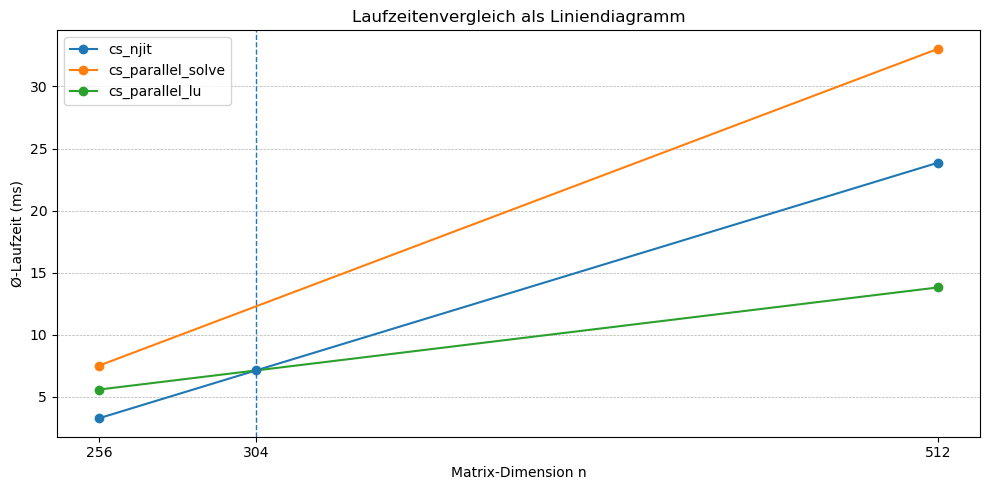

In [13]:
# Berechnung der Geradenparameter für die beiden Linien
n1, n2 = 256 , 512
# cs_njit
y1_njit, y2_njit = run_times_means['cs_njit']
m1 = (y2_njit - y1_njit) / (n2 - n1)
b1 = y1_njit - m1 * n1
# cs_parallel_lu
y1_lu, y2_lu = run_times_means['cs_parallel_lu']
m2 = (y2_lu - y1_lu) / (n2 - n1)
b2 = y1_lu - m2 * n1

# Schnittpunkt berechnen
n_int = (b2 - b1) / (m1 - m2)
y_int = m1 * n_int + b1

# Plot: Liniendiagramm aller Funktionen
plt.figure(figsize=(10, 5))
for func, times in run_times_means.items():
    if func != 'custom_solve':
        plt.plot(dimensions, times, marker='o', label=func)

# Schnittpunkt markieren
plt.scatter([n_int], [y_int], zorder=5)
plt.axvline(n_int, linestyle='--', linewidth=1)

plt.xlabel('Matrix-Dimension n')
plt.ylabel('Ø-Laufzeit (ms)')
plt.title('Laufzeitenvergleich als Liniendiagramm')
plt.xticks([n1, n_int, n2], [str(n1), f'{n_int:.0f}', str(n2)])
plt.legend()
plt.grid(axis='y', which='major', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

<!-- END QUESTION -->

Führen Sie alle Zellen im Notebook aus und speichern Sie es.  
Danach können Sie mit der folgenden Zelle eine HTML-Datei erstellen.  
Eine mögliche `UserWarning` können Sie ignorieren.  
Bitte geben Sie das Notebook als `.ipynb` und `.html` Datei ab.

In [ ]:
#!jupyter nbconvert --to html EA3.ipynb